In [61]:
# Package import
import scipy.io
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.registration import phase_cross_correlation
import os
import time
import helper_functions as hf
import importlib
importlib.reload(hf)

<module 'helper_functions' from 'c:\\Users\\leo.sperber\\FUSclass\\modelV1\\helper_functions.py'>

In [60]:
data_directory = r"D:\SecundoUni"  # Adjust if needed, e.g., if files are scattered
data_output_dir = r"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\secondtry"
SPLIT_MODE = 'acq' # Split mode acquistition-wise: 'acq' or middle split per acquisition: 'mid'
HIGH_PASS = 'nohp'
TOP = 99
BOTTOM = 1
TARGET_SIZE = 112
SPLIT = 0.7
DATASET_NAME = f"{TARGET_SIZE}x{TARGET_SIZE}_clip{TOP}_{BOTTOM}_split{SPLIT}_mode{SPLIT_MODE}_{HIGH_PASS}"

In [16]:
import numpy as np
from sklearn.decomposition import PCA

def pca_denoise(images, n_components=None, var_keep=0.95):
    """
    Perform PCA-based denoising on a 3D array (T, H, W).

    Parameters
    ----------
    images : np.ndarray
        Data array of shape (n_frames, H, W).
    n_components : int or None
        Number of PCA components to retain. If None,
        the number will be chosen to keep `var_keep` of total variance.
    var_keep : float
        Fraction of variance to retain when n_components is None.

    Returns
    -------
    images_denoised : np.ndarray
        Data reconstructed after PCA denoising.
    pca : sklearn.decomposition.PCA
        The fitted PCA object (useful for diagnostics).
    """
    T, H, W = images.shape
    # Flatten spatial dimensions
    X = images.reshape(T, H * W)

    # Fit PCA across frames (time is samples)
    pca = PCA()
    X_trans = pca.fit_transform(X)

    available_components = X_trans.shape[1]

    # Choose # of components to keep
    if n_components is None:
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        n_components = np.searchsorted(cumvar, var_keep) + 1
        n_components = min(n_components, available_components)  # Cap to available

    # Reconstruct using selected components
    X_rec = pca.inverse_transform(X_trans[:, :n_components])

    # Reshape back to (T, H, W)
    images_denoised = X_rec.reshape(T, H, W)

    return images_denoised, pca

In [4]:
import numpy as np
from sklearn.decomposition import PCA

def pca_denoise(images, n_components=None, var_keep=0.70):
    """
    Perform PCA-based denoising on a 3D array (T, H, W).

    Parameters
    ----------
    images : np.ndarray
        Data array of shape (n_frames, H, W).
    n_components : int or None
        Number of PCA components to retain. If None,
        the number will be chosen to keep `var_keep` of total variance.
    var_keep : float
        Fraction of variance to retain when n_components is None.

    Returns
    -------
    images_denoised : np.ndarray
        Data reconstructed after PCA denoising.
    pca : sklearn.decomposition.PCA
        The fitted PCA object (useful for diagnostics).
    """
    T, H, W = images.shape
    # Flatten spatial dimensions
    X = images.reshape(T, H * W)

    # Fit PCA across frames (time is samples)
    pca = PCA()
    pca.fit(X)  # Fit on full to get cumvar

    # Determine n_components
    available_components = pca.n_components_
    if n_components is None:
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        n_components = np.searchsorted(cumvar, var_keep) + 1
        n_components = min(n_components, available_components)

    # Transform with full, then subset
    X_trans = pca.transform(X)  # (T, available)

    # Manual inverse with subset
    X_subset = X_trans[:, :n_components]  # (T, n_components)
    components_subset = pca.components_[:n_components, :]  # (n_components, H*W)
    explained_variance_subset = pca.explained_variance_[:n_components]

    # Inverse (whiten=False, default)
    X_rec = X_subset @ components_subset + pca.mean_

    # Reshape back to (T, H, W)
    images_denoised = X_rec.reshape(T, H, W)

    return images_denoised, pca

In [12]:
import torch

def zscore_norm(cbv_data, eps=1e-8):
    # Ensure cbv_data is a tensor
    if not torch.is_tensor(cbv_data):
        cbv_data = torch.tensor(cbv_data)

    mean = cbv_data.mean()
    std  = cbv_data.std()

    # Use tensor comparison instead of Python float comparison
    if std.item() < eps:
        print("Warning: ROI std very small → using min-max fallback")
        data_min = cbv_data.min()
        data_max = cbv_data.max()
        cbv_norm = (cbv_data - data_min) / (data_max - data_min + eps)
    else:
        cbv_norm = (cbv_data - mean) / (std + eps)

    return cbv_norm

In [ ]:
# Load + Pre-process data (ACQ WISE SPLIT - %CBV + 0-1 normalisation with percentile clipping + 112x112 interpolation resizing)
import scipy.io
import numpy as np
import importlib
import torch
import torch.nn.functional as F
import os
import glob
from scipy import signal
import random
import helper_functions as hf
importlib.reload(hf)

# Find all Secundo data acquisitions (no .mat extension)
mat_files = glob.glob(os.path.join(data_directory, "prepdata_Se*"))
if not mat_files:
    raise ValueError("No files starting with prepdata_Se found in the directory!")
print(f"Found {len(mat_files)} files.")

# Load, compute %CBV on original size, normalize per acquisition, then interpolate to 112x112
all_images = []
all_labels = []
acquisition_indices_per_file = []  # Track cumulative starts for indices
current_frame_offset = 0
acquisition_indices = []  # Will build full tensor here
file_idx = 0  # Acquisition index (0 to len(mat_files)-1, only for kept files)

# Your existing file list logic stays the same
mat_files = list(all_mat_data.keys())
print(f"Found {len(mat_files)} preloaded files.")

for mat_path in mat_files:
    mat_data = all_mat_data[mat_path] 
    print(f"Processing file {file_idx}: {mat_path}")
    doppler_data = mat_data['Doppler']
    doppler_data = doppler_data[np.newaxis, :, :, :]
    images = np.transpose(doppler_data, (3, 0, 2, 1)).astype(np.float32)  # (N_images, 1, H_var, 128)
    images = np.log10(images)
    
    labels = mat_data['Label']
    labels_arr = np.array(labels).flatten().astype(np.int64)  # (N_labels,)
    
    # Shave 1 frames off end of images in case of mismatch between images and labels
    images, labels_arr = hf.mismatch(images, labels_arr)

    print(f"Raw images range: min={images.min():.6f}, max={images.max():.6f}")
    #vimages, _ = pca_denoise(images.squeeze())
    # Take out baseline and compute CBV % change relative to baseline
    cbv_data, labels_arr = hf.delta_cbv(images, labels_arr, use_log = False, robust = False)
    print(np.shape(cbv_data))
    
    print(f"CBV images range: min={cbv_data.min():.6f}, max={cbv_data.max():.6f}")
    if cbv_data.size > 0:  # Avoid empty
        if HIGH_PASS == 'hp':
            # Temporal high pass
            cbv_data = hf.high_pass(cbv_data)

        # cbv_data, _ = pca_denoise(cbv_data)
        # Clip 95th top and 5th bottom percentiles and normalize
        cbv_data = hf.clip(cbv_data, BOTTOM, TOP)

        print(f"CBV after clip range: min={cbv_data.min():.6f}, max={cbv_data.max():.6f}")

        # Convert to tensor and interpolate
        #cbv_tensor = hf.tensor_interpolate(cbv_data.squeeze(), target_size=112)
        cbv_tensor = hf.tensor_pad_or_crop(cbv_data, target_size=TARGET_SIZE)
        cbv_tensor = hf.norm(cbv_tensor)
    

        # Append aligned data
        all_images.append(cbv_tensor)
        all_labels.append(torch.from_numpy(labels_arr))
        
        # Track acquisition: Assign current file_idx to all frames in this file
        file_acq_indices = torch.full((cbv_data.shape[0],), file_idx, dtype=torch.int64)
        acquisition_indices.append(file_acq_indices)
        
        # For offsets (if needed later, e.g., for splitting)
        acquisition_indices_per_file.append(current_frame_offset)
        current_frame_offset += cbv_data.shape[0]
        file_idx += 1  # Only increment if kept
        
        print(f"  - Resized %CBV shape: {cbv_tensor.shape}, Labels shape: {labels_arr.shape}, Acq idx: {file_idx-1}")
    else:
        print(f"  - Acq {file_idx}: Empty data, skipping normalization.")
        cbv_normalized = np.zeros_like(cbv_data)

# Concatenate into big tensors (only kept files)
big_images = torch.cat(all_images, dim=0)  # (total_frames, 1, 112, 112)
big_labels = torch.cat(all_labels, dim=0)  # (total_frames,)
big_acquisition_indices = torch.cat(acquisition_indices, dim=0)  # (total_frames,)

print(f"\nBig images tensor shape: {big_images.shape}")
print(f"Big labels tensor shape: {big_labels.shape}")
print(f"Big acquisition indices shape: {big_acquisition_indices.shape}")

if SPLIT_MODE == 'acq':
    print("Splitting data acquisition-wise")
    train_mask, test_mask = hf.acq_wise_split(big_acquisition_indices, 42, 0.8)
else:
    print("Splitting data with a middle split 40% train 20% test 40% train per acquisition")
    train_mask, test_mask = hf.mid_split_whole(big_acquisition_indices, 0.8)

# Extract train and test tensors
train_images = big_images[train_mask]
train_labels = big_labels[train_mask]
train_acqs = big_acquisition_indices[train_mask]

test_images = big_images[test_mask]
test_labels = big_labels[test_mask]
test_acqs = big_acquisition_indices[test_mask]

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Train acquisiton indices shape: {train_acqs.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Test acquisiton indices shape: {train_acqs.shape}")

torch.save(train_images, os.path.join(data_output_dir, f"train_images_{DATASET_NAME}.pt"))
torch.save(train_labels, os.path.join(data_output_dir, f"train_labels_{DATASET_NAME}.pt"))
torch.save(test_images, os.path.join(data_output_dir, f"test_images_{DATASET_NAME}.pt"))
torch.save(test_labels, os.path.join(data_output_dir, f"test_labels_{DATASET_NAME}.pt"))
torch.save(train_acqs, os.path.join(data_output_dir, f"train_acq_ids_{DATASET_NAME}.pt"))
torch.save(test_acqs, os.path.join(data_output_dir, f"test_acq_ids_{DATASET_NAME}.pt"))
print("Train and test tensors saved to disk")

Found 12 files.
Found 12 preloaded files.
Processing file 0: D:\SecundoUni\prepdata_Se01072020_DS1masked.mat
  - Match confirmed: 7500 frames and labels.


ValueError: too many values to unpack (expected 3)

In [20]:
def get_or_create_roi_mask(images, file_idx):
    """
    Returns the ROI mask for a given acquisition.
    - If roi_{file_idx}.npy already exists → loads it
    - Else → launches the interactive drawing and then loads it
    """
    mask_path = f'roi_{file_idx}.npy'
    
    if os.path.exists(mask_path):
        print(f"ROI mask found → loading {mask_path}")
        mask = np.load(mask_path)
    else:
        print(f"No ROI mask found → starting interactive drawing for acquisition {file_idx}")
        hf.create_roi(images, file_idx)          # this saves the .npy file
        mask = np.load(mask_path)
        print(f"Mask created and loaded → {mask_path}")
    
    return mask

In [ ]:
# Find all Secundo data acquisitions (no .mat extension)
mat_files = glob.glob(os.path.join(data_directory, "prepdata_Se*"))
if not mat_files:
    raise ValueError("No files starting with prepdata_Se found in the directory!")
print(f"Found {len(mat_files)} files.")

for mat_path in mat_files:
    print(f"Processing file {file_idx}: {mat_path}")
    mat_data = scipy.io.loadmat(mat_path)

In [8]:
# Pre-load all data files
import scipy.io
import numpy as np
import importlib
import torch
import torch.nn.functional as F
import os
import glob
from scipy import signal
import random
import helper_functions as hf
import pickle
importlib.reload(hf)

cache_path = os.path.join(data_directory, "cached_datasets.pkl")

# Find all matching .mat files
mat_files = glob.glob(os.path.join(data_directory, "prepdata_Se*"))
if not mat_files:
    raise ValueError("No files starting with prepdata_Se found in the directory!")

print(f"Found {len(mat_files)} files to load...")

# Load all into memory
all_mat_data = {}
for mat_path in mat_files:
    base_name = os.path.splitext(os.path.basename(mat_path))[0]
    print(f"Loading {base_name}")
    all_mat_data[mat_path] = scipy.io.loadmat(mat_path)

print("✅ All .mat files loaded into memory.")

Found 12 files to load...
Loading prepdata_Se01072020_DS1masked
Loading prepdata_Se04082020_DS1masked
Loading prepdata_Se05082020_DS1masked
Loading prepdata_Se22092020_DS1masked
Loading prepdata_Se23072020_DS1masked
Loading prepdata_Se24062020_DS1masked
Loading prepdata_Se25062020_DS1masked
Loading prepdata_Se26062020_DS1masked
Loading prepdata_Se27072020_DS1masked
Loading prepdata_Se29062020_DS1masked
Loading prepdata_Se29072020_DS1masked
Loading prepdata_Se30062020_DS1masked
✅ All .mat files loaded into memory.


In [41]:
file_idx = 0  # Acquisition index (0 to len(mat_files)-1, only for kept files)

# Your existing file list logic stays the same
mat_files = list(all_mat_data.keys())
print(f"Found {len(mat_files)} preloaded files.")

for mat_path in mat_files:
    mat_data = all_mat_data[mat_path] 
    print(f"Processing file {file_idx}: {mat_path}")
    doppler_data = mat_data['Doppler']
    doppler_data = doppler_data[np.newaxis, :, :, :]
    images = np.transpose(doppler_data, (3, 0, 2, 1)).astype(np.float32)  # (N_images, 1, H_var, 128)
    images = np.log10(images)
    plt.imshow(images[0, 0, :, :], cmap='viridis')  # pick slice [0,0,:,:] since shape is (N,1,H,W)
    plt.colorbar()
    plt.title(f"Frame Acquisition {file_idx}")
    plt.savefig(f"frame_acquisition_{file_idx}.png")
    plt.close()  # close figure to avoid overlap
    file_idx += 1

Found 12 preloaded files.
Processing file 0: D:\SecundoUni\prepdata_Se01072020_DS1masked.mat
Processing file 1: D:\SecundoUni\prepdata_Se04082020_DS1masked.mat
Processing file 2: D:\SecundoUni\prepdata_Se05082020_DS1masked.mat
Processing file 3: D:\SecundoUni\prepdata_Se22092020_DS1masked.mat
Processing file 4: D:\SecundoUni\prepdata_Se23072020_DS1masked.mat
Processing file 5: D:\SecundoUni\prepdata_Se24062020_DS1masked.mat
Processing file 6: D:\SecundoUni\prepdata_Se25062020_DS1masked.mat
Processing file 7: D:\SecundoUni\prepdata_Se26062020_DS1masked.mat
Processing file 8: D:\SecundoUni\prepdata_Se27072020_DS1masked.mat
Processing file 9: D:\SecundoUni\prepdata_Se29062020_DS1masked.mat
Processing file 10: D:\SecundoUni\prepdata_Se29072020_DS1masked.mat
Processing file 11: D:\SecundoUni\prepdata_Se30062020_DS1masked.mat


In [59]:
%matplotlib qt
# Load + Pre-process data MASKING VERSION
import scipy.io
import numpy as np
import importlib
import torch
import torch.nn.functional as F
import os
import glob
from scipy import signal
import random
import helper_functions as hf
import pickle
importlib.reload(hf)

# Load, compute %CBV on original size, normalize per acquisition, then interpolate to 112x112
all_images = []
all_labels = []
all_baselines = []
acquisition_indices_per_file = []  # Track cumulative starts for indices
current_frame_offset = 0
acquisition_indices = []  # Will build full tensor here
file_idx = 0  # Acquisition index (0 to len(mat_files)-1, only for kept files)

# Your existing file list logic stays the same
mat_files = list(all_mat_data.keys())
print(f"Found {len(mat_files)} preloaded files.")

for mat_path in mat_files:
    mat_data = all_mat_data[mat_path] 
    print(f"Processing file {file_idx}: {mat_path}")
    doppler_data = mat_data['Doppler']
    doppler_data = doppler_data[np.newaxis, :, :, :]
    images = np.transpose(doppler_data, (3, 0, 2, 1)).astype(np.float32)  # (N_images, 1, H_var, 128)
    images = np.log10(images)
    
    labels = mat_data['Label']
    labels_arr = np.array(labels).flatten().astype(np.int64)  # (N_labels,)
    
    
    # Shave 1 frames off end of images in case of mismatch between images and labels
    images, labels_arr = hf.mismatch(images, labels_arr)
    print(f"Raw images range: min={images.min():.6f}, max={images.max():.6f}")

    images = hf.np_pad_or_crop_to_square(images, target_size=TARGET_SIZE)
    print(np.shape(images))
    roi_mask = get_or_create_roi_mask(images, file_idx)

    # Compute per acquisition baseline map
    baseline_idx = (labels_arr == -1)
    baseline_frames = images[baseline_idx] 
    images, _ = pca_denoise(images.squeeze())
    # Take out baseline and compute CBV % change relative to baseline
    cbv_data, labels_arr = hf.delta_cbv_roi(images, labels_arr, roi_mask, use_log = False, robust = False)
    # cbv_data, labels_arr = hf.delta_cbv_roi_adaptive(images, labels_arr, roi_mask, window_sec = 20,
    # acquisition_rate_hz = 2.5, use_log = False, robust = True)

    cbv_data *= roi_mask[None, :, :]
    # cbv_data = hf.pillbox_filter(cbv_data,  radius=3)
    # cbv_data *= roi_mask[None, :, :]
    print(f"CBV images range: min={cbv_data.min():.6f}, max={cbv_data.max():.6f}")

    if cbv_data.size > 0:  # Avoid empty
        if HIGH_PASS == 'hp':
            # Temporal high pass
            cbv_data = hf.high_pass(cbv_data)
        cbv_data *= roi_mask[None, :, :]
        # Clip 95th top and 5th bottom percentiles and normalize
        cbv_data = hf.clip(cbv_data, BOTTOM, TOP)
        # print(f"CBV after clip range: min={cbv_data.min():.6f}, max={cbv_data.max():.6f}")
        # cbv_data *= roi_mask[None, :, :]
        cbv_data = hf.normalize_cbv_in_roi(cbv_data, roi_mask, 'zscore')

        cbv_tensor = torch.from_numpy(cbv_data[:, np.newaxis, :, :].astype(np.float32))

        baseline_frames = hf.pillbox_filter(baseline_frames.squeeze(), radius = 3)
        baseline_frames = baseline_frames * roi_mask[None, :, :]
        
        baseline_frames = hf.clip(baseline_frames, BOTTOM, TOP)
        baseline_frames = hf.normalize_cbv_in_roi(baseline_frames, roi_mask, 'zscore')

        baseline_map = np.mean(baseline_frames, axis=0)  # shape (1, H, W)

        # Append aligned data
        all_images.append(cbv_tensor)
        all_labels.append(torch.from_numpy(labels_arr))

        baseline_tensor = torch.from_numpy(baseline_map[np.newaxis, :, :].astype(np.float32))  # (1, H, W)
        all_baselines.append(baseline_tensor)
        
        # Track acquisition: Assign current file_idx to all frames in this file
        file_acq_indices = torch.full((cbv_data.shape[0],), file_idx, dtype=torch.int64)
        acquisition_indices.append(file_acq_indices)
        
        # For offsets (if needed later, e.g., for splitting)
        acquisition_indices_per_file.append(current_frame_offset)
        current_frame_offset += cbv_data.shape[0]
        file_idx += 1  # Only increment if kept

        
        print(f"  - Resized %CBV shape: {cbv_tensor.shape}, Labels shape: {labels_arr.shape}, Acq idx: {file_idx-1}")
    else:
        print(f"  - Acq {file_idx}: Empty data, skipping normalization.")
        cbv_normalized = np.zeros_like(cbv_data)

# Concatenate into big tensors (only kept files)
big_images = torch.cat(all_images, dim=0)  # (total_frames, 1, 112, 112)
big_labels = torch.cat(all_labels, dim=0)  # (total_frames,)
big_acquisition_indices = torch.cat(acquisition_indices, dim=0)  # (total_frames,)
big_baselines = torch.stack(all_baselines, dim=0)  # (n_acqs, 1, 112, 112)

print(f"Big baseline tensor shape: {big_baselines.shape}")
print(f"\nBig images tensor shape: {big_images.shape}")
print(f"Big labels tensor shape: {big_labels.shape}")
print(f"Big acquisition indices shape: {big_acquisition_indices.shape}")

if SPLIT_MODE == 'acq':
    print("Splitting data acquisition-wise")
    train_mask, test_mask = hf.acq_wise_split(big_acquisition_indices, 42, 0.8)
else:
    print("Splitting data with a middle split 40% train 20% test 40% train per acquisition")
    train_mask, test_mask = hf.mid_split_whole(big_acquisition_indices, 0.8)

# Extract train and test tensors
train_images = big_images[train_mask]
train_labels = big_labels[train_mask]
train_acqs = big_acquisition_indices[train_mask]

test_images = big_images[test_mask]
test_labels = big_labels[test_mask]
test_acqs = big_acquisition_indices[test_mask]

train_acqs_unique = torch.unique(train_acqs)
test_acqs_unique = torch.unique(test_acqs)

train_baseline = big_baselines[train_acqs_unique]
test_baseline = big_baselines[test_acqs_unique]

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Train acquisiton indices shape: {train_acqs.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Test acquisiton indices shape: {train_acqs.shape}")

torch.save(train_images, os.path.join(data_output_dir, f"train_images_{DATASET_NAME}.pt"))
torch.save(train_labels, os.path.join(data_output_dir, f"train_labels_{DATASET_NAME}.pt"))
torch.save(test_images, os.path.join(data_output_dir, f"test_images_{DATASET_NAME}.pt"))
torch.save(test_labels, os.path.join(data_output_dir, f"test_labels_{DATASET_NAME}.pt"))
torch.save(train_acqs, os.path.join(data_output_dir, f"train_acq_ids_{DATASET_NAME}.pt"))
torch.save(test_acqs, os.path.join(data_output_dir, f"test_acq_ids_{DATASET_NAME}.pt"))

torch.save(train_baseline, os.path.join(data_output_dir, f"train_baseline_{DATASET_NAME}.pt"))
torch.save(test_baseline, os.path.join(data_output_dir, f"test_baseline_{DATASET_NAME}.pt"))

print("Train and test tensors saved to disk")
%matplotlib inline

Found 12 preloaded files.
Processing file 0: D:\SecundoUni\prepdata_Se01072020_DS1masked.mat
  - Match confirmed: 7500 frames and labels.
Raw images range: min=0.942446, max=3.634640
Function pad shape:  (7500, 1, 112, 112)
(7500, 1, 112, 112)
ROI mask found → loading roi_0.npy


c:\Users\leo.sperber\FUSclass\modelV1\helper_functions.py:581: RuntimeWarning: Mean of empty slice
  baseline_map = np.nanmean(baseline_frames, axis=0, keepdims=True)


Acquisition ΔCBV (in ROI) → min: -42.108%, max: +75.592% | Frames kept: 6997 | ROI pixels: 2161
CBV images range: min=-42.108021, max=75.591873
ROI normalization (zscore): mean=-0.0063, std=1.0546, min=-2.087, max=2.106
Pillbox filter applied | radius=3px | kernel=7×7 (1.0 pixels) | frames=503
ROI normalization (zscore): mean=1.4416, std=0.2902, min=1.109, max=2.070
  - Resized %CBV shape: torch.Size([6997, 1, 112, 112]), Labels shape: (6997,), Acq idx: 0
Processing file 1: D:\SecundoUni\prepdata_Se04082020_DS1masked.mat
  - MISMATCH: Images=9000, Labels=8999. Shaving to 8999 frames.
Raw images range: min=0.924056, max=3.774664
Function pad shape:  (8999, 1, 112, 112)
(8999, 1, 112, 112)
ROI mask found → loading roi_1.npy


c:\Users\leo.sperber\FUSclass\modelV1\helper_functions.py:581: RuntimeWarning: Mean of empty slice
  baseline_map = np.nanmean(baseline_frames, axis=0, keepdims=True)


Acquisition ΔCBV (in ROI) → min: -46.188%, max: +100.275% | Frames kept: 8563 | ROI pixels: 2296
CBV images range: min=-46.188087, max=100.274712
ROI normalization (zscore): mean=-0.0126, std=1.5847, min=-3.133, max=3.162
Pillbox filter applied | radius=3px | kernel=7×7 (1.0 pixels) | frames=436
ROI normalization (zscore): mean=1.4591, std=0.3169, min=1.117, max=2.238
  - Resized %CBV shape: torch.Size([8563, 1, 112, 112]), Labels shape: (8563,), Acq idx: 1
Processing file 2: D:\SecundoUni\prepdata_Se05082020_DS1masked.mat
  - MISMATCH: Images=7500, Labels=7499. Shaving to 7499 frames.
Raw images range: min=0.932584, max=3.675017
Function pad shape:  (7499, 1, 112, 112)
(7499, 1, 112, 112)
ROI mask found → loading roi_2.npy


...

Acquisition ΔCBV (in ROI) → min: -41.234%, max: +53.265% | Frames kept: 7006 | ROI pixels: 2135
CBV images range: min=-41.234367, max=53.265110
ROI normalization (zscore): mean=-0.0053, std=1.1895, min=-2.146, max=2.226
Pillbox filter applied | radius=3px | kernel=7×7 (1.0 pixels) | frames=494
ROI normalization (zscore): mean=1.4220, std=0.2802, min=1.108, max=2.074
  - Resized %CBV shape: torch.Size([7006, 1, 112, 112]), Labels shape: (7006,), Acq idx: 9
Processing file 10: D:\SecundoUni\prepdata_Se29072020_DS1masked.mat
  - Match confirmed: 8752 frames and labels.
Raw images range: min=0.943836, max=3.811481
Function pad shape:  (8752, 1, 112, 112)
(8752, 1, 112, 112)
ROI mask found → loading roi_10.npy


c:\Users\leo.sperber\FUSclass\modelV1\helper_functions.py:581: RuntimeWarning: Mean of empty slice
  baseline_map = np.nanmean(baseline_frames, axis=0, keepdims=True)


Acquisition ΔCBV (in ROI) → min: -29.399%, max: +37.972% | Frames kept: 8283 | ROI pixels: 2112
CBV images range: min=-29.399307, max=37.972057
ROI normalization (zscore): mean=-0.0149, std=1.7581, min=-3.302, max=3.329
Pillbox filter applied | radius=3px | kernel=7×7 (1.0 pixels) | frames=469
ROI normalization (zscore): mean=1.4878, std=0.2914, min=1.117, max=2.104
  - Resized %CBV shape: torch.Size([8283, 1, 112, 112]), Labels shape: (8283,), Acq idx: 10
Processing file 11: D:\SecundoUni\prepdata_Se30062020_DS1masked.mat
  - Match confirmed: 7500 frames and labels.
Raw images range: min=0.941719, max=3.559422
Function pad shape:  (7500, 1, 112, 112)
(7500, 1, 112, 112)
ROI mask found → loading roi_11.npy


c:\Users\leo.sperber\FUSclass\modelV1\helper_functions.py:581: RuntimeWarning: Mean of empty slice
  baseline_map = np.nanmean(baseline_frames, axis=0, keepdims=True)


Acquisition ΔCBV (in ROI) → min: -30.613%, max: +36.848% | Frames kept: 7038 | ROI pixels: 2247
CBV images range: min=-30.612864, max=36.848167
ROI normalization (zscore): mean=-0.0085, std=1.5653, min=-2.880, max=2.994
Pillbox filter applied | radius=3px | kernel=7×7 (1.0 pixels) | frames=462
ROI normalization (zscore): mean=1.3951, std=0.2343, min=1.106, max=1.918
  - Resized %CBV shape: torch.Size([7038, 1, 112, 112]), Labels shape: (7038,), Acq idx: 11
Big baseline tensor shape: torch.Size([12, 1, 112, 112])

Big images tensor shape: torch.Size([86932, 1, 112, 112])
Big labels tensor shape: torch.Size([86932])
Big acquisition indices shape: torch.Size([86932])
Splitting data acquisition-wise
Number of acquisitions: 12
Train acquisitions: 9
Test acquisitions: 3
Train images shape: torch.Size([63089, 1, 112, 112])
Train labels shape: torch.Size([63089])
Train acquisiton indices shape: torch.Size([63089])
Test images shape: torch.Size([23843, 1, 112, 112])
Test labels shape: torch.Siz

In [62]:
# Re Load data file
import torch
import os

# Set the directory where the .pt files were saved
directory = r"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\secondtry" # Adjust if needed

DATASET_NAME = f"112x112_clip99_1_split0.7_modeacq_nohp"

# Paths to the saved files
train_images_path = os.path.join(directory, f"train_images_{DATASET_NAME}.pt")
train_labels_path= os.path.join(directory, f"train_labels_{DATASET_NAME}.pt")
test_images_path = os.path.join(directory, f"test_images_{DATASET_NAME}.pt")
test_labels_path= os.path.join(directory, f"test_labels_{DATASET_NAME}.pt")
train_acqs_path = os.path.join(directory, f"train_acq_ids_{DATASET_NAME}.pt")
test_acqs_path = os.path.join(directory, f"test_acq_ids_{DATASET_NAME}.pt")

# Load the tensors
train_images = torch.load(train_images_path)
train_labels = torch.load(train_labels_path)
test_images = torch.load(test_images_path)
test_labels = torch.load(test_labels_path)
train_acqs = torch.load(train_acqs_path)
test_acqs = torch.load(test_acqs_path)
# Print shapes to confirm
print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Train acquisition indices shape: {train_acqs.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Test acquisition indices shape: {test_acqs.shape}")

Train images shape: torch.Size([63089, 1, 112, 112])
Train labels shape: torch.Size([63089])
Train acquisition indices shape: torch.Size([63089])
Test images shape: torch.Size([23843, 1, 112, 112])
Test labels shape: torch.Size([23843])
Test acquisition indices shape: torch.Size([23843])


In [89]:
print(test_acqs.size())

torch.Size([23843])


In [78]:
test_images.size()

torch.Size([23843, 1, 112, 112])

In [95]:
test_acqs

tensor([ 0,  0,  0,  ..., 10, 10, 10])

In [27]:
import torch

def expand_baseline_to_frames(images, acqs, baseline):
    """
    Expand baseline frames (one per acquisition) to match the number of image frames.
    
    Args:
        images (torch.Tensor): [N_frames, C, H, W]
        acqs (torch.Tensor): [N_frames] acquisition ID per frame (not necessarily 0..N_acqs-1)
        baseline (torch.Tensor): [N_acqs, C, H, W] one baseline per acquisition

    Returns:
        torch.Tensor: [N_frames, C, H, W] baseline repeated for each frame's acquisition
    """
    acqs = acqs.clone().long()

    # Normalize acquisition IDs → 0..N_unique-1 range
    unique_acqs, inverse_indices = torch.unique(acqs, return_inverse=True)

    if unique_acqs.numel() != baseline.shape[0]:
        raise ValueError(
            f"Number of unique acquisitions in acqs ({unique_acqs.numel()}) "
            f"does not match number of baseline frames ({baseline.shape[0]})."
        )

    # Now inverse_indices[i] = baseline index for frame i
    expanded_baseline = baseline[inverse_indices]

    # Sanity check
    assert expanded_baseline.shape == images.shape, (
        f"Expanded baseline shape {expanded_baseline.shape} "
        f"does not match images shape {images.shape}"
    )

    return expanded_baseline


# ---------- Example usage ----------
train_baseline_expanded = expand_baseline_to_frames(train_images, train_acqs, train_baseline)
test_baseline_expanded  = expand_baseline_to_frames(test_images,  test_acqs,  test_baseline)

print(f"train_baseline_expanded shape: {train_baseline_expanded.shape}")
print(f"test_baseline_expanded shape:  {test_baseline_expanded.shape}")

train_baseline_expanded shape: torch.Size([134528, 1, 112, 112])
test_baseline_expanded shape:  torch.Size([33427, 1, 112, 112])


In [126]:
# Pause/work distributions
print("Train labels distribution:")
hf.pause_work_distrib(train_labels)
print("Test label distribution:")
hf.pause_work_distrib(test_labels)


Train labels distribution:
Label 0: 117574 patches (87.40%)
Label 1: 16954 patches (12.60%)
Test label distribution:
Label 0: 29960 patches (89.63%)
Label 1: 3467 patches (10.37%)


In [122]:
train_acqs.unique()

tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 11])

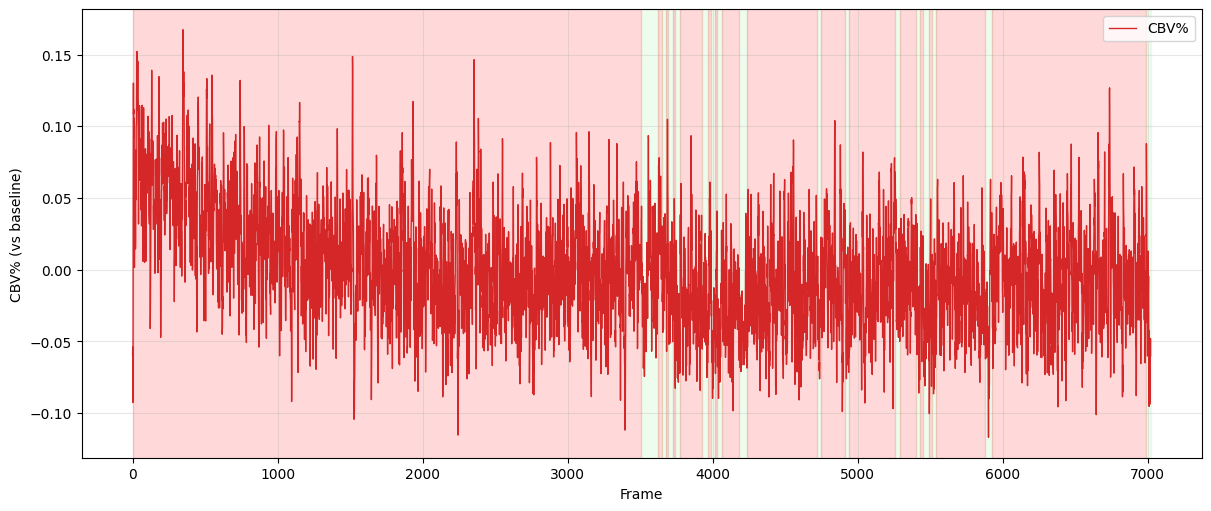

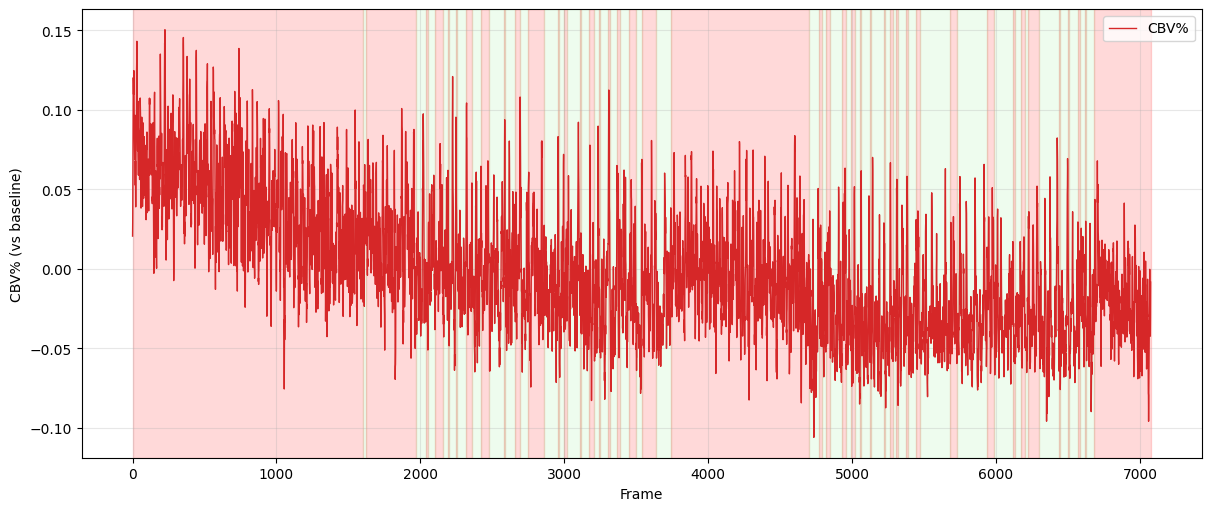

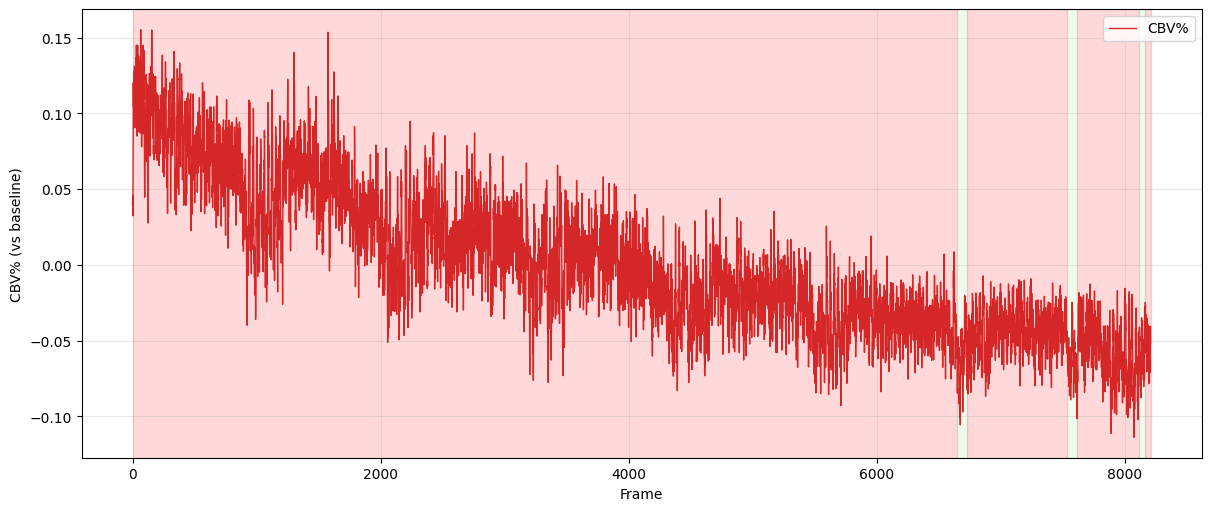

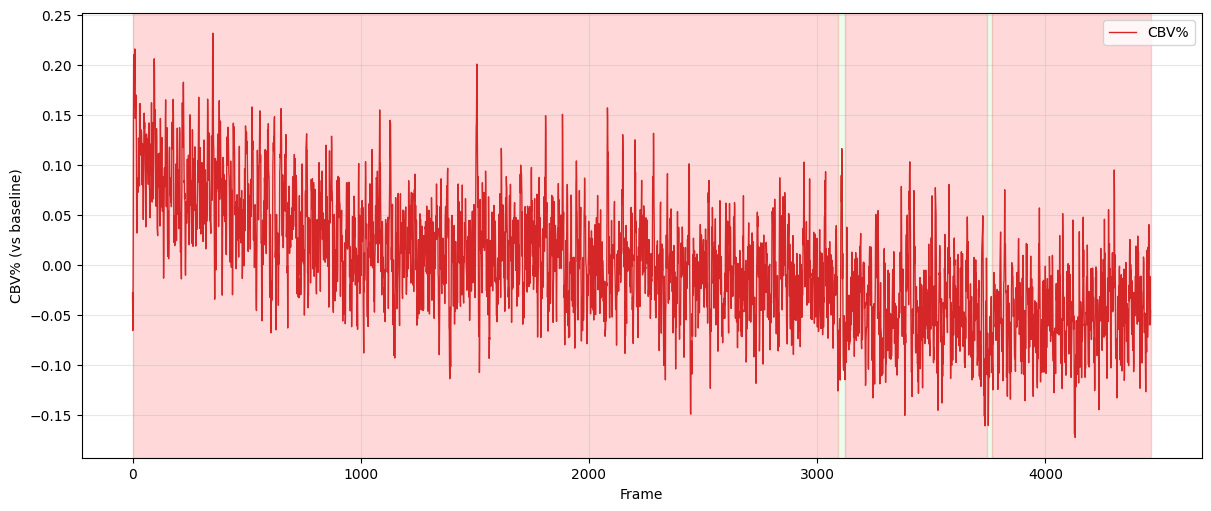

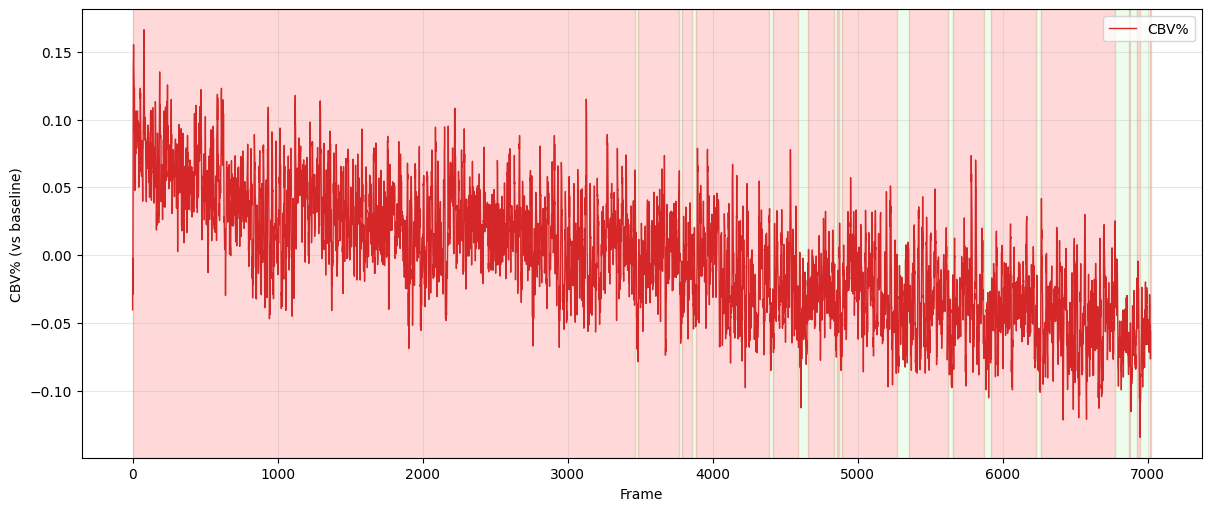

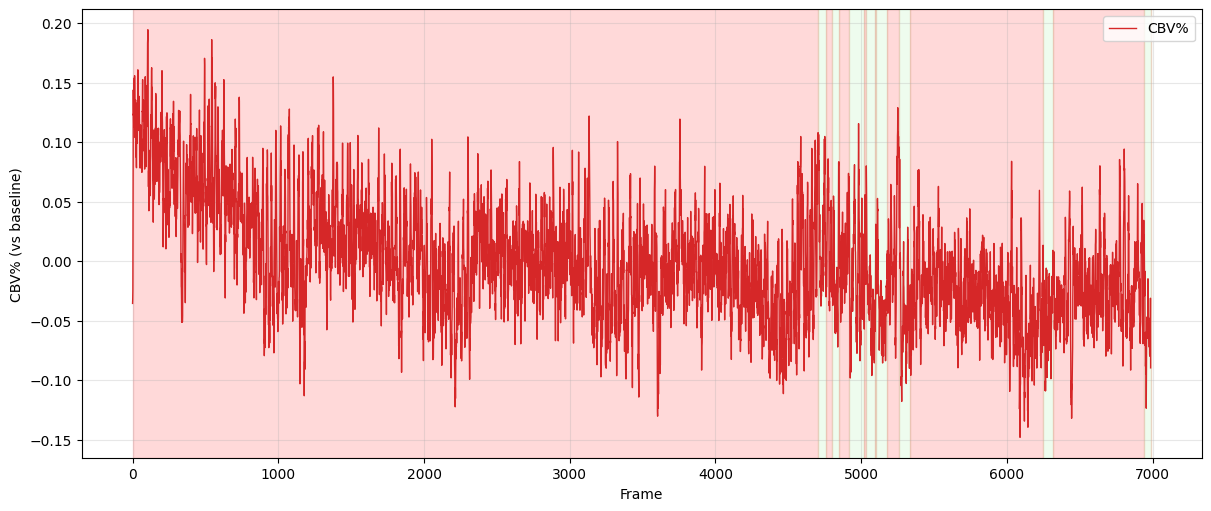

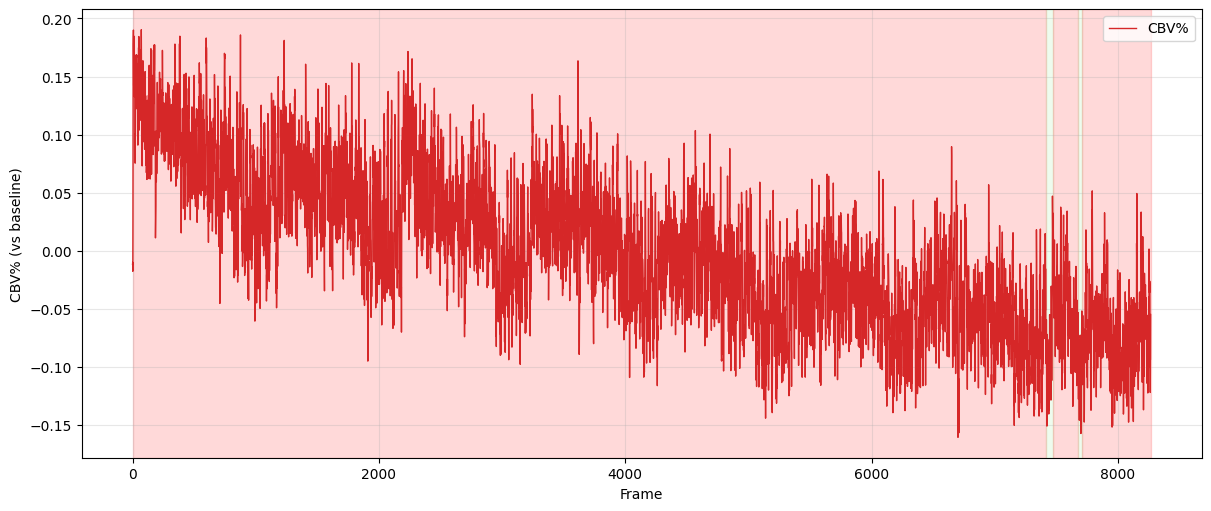

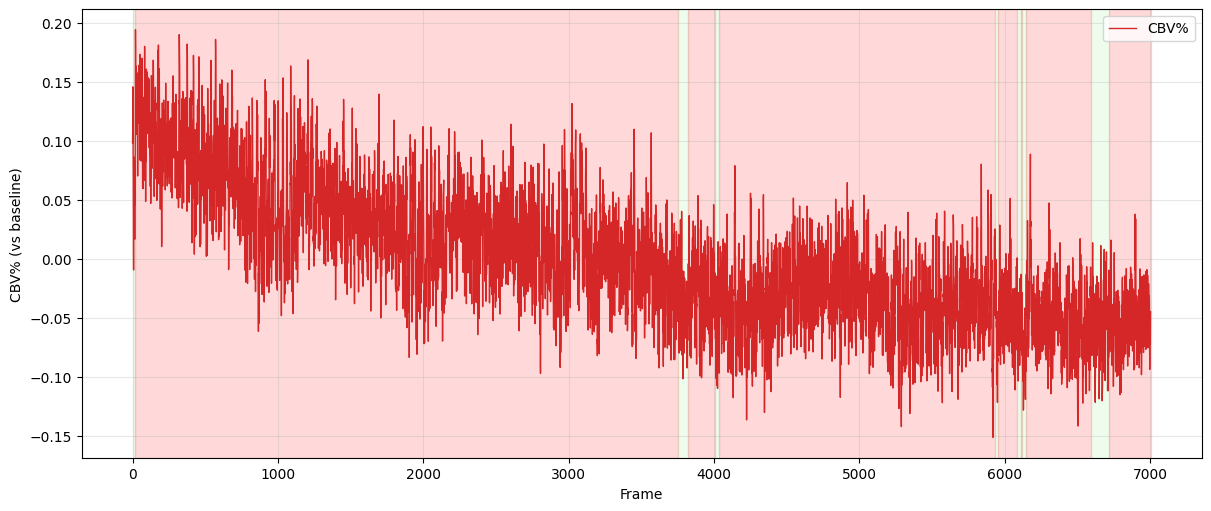

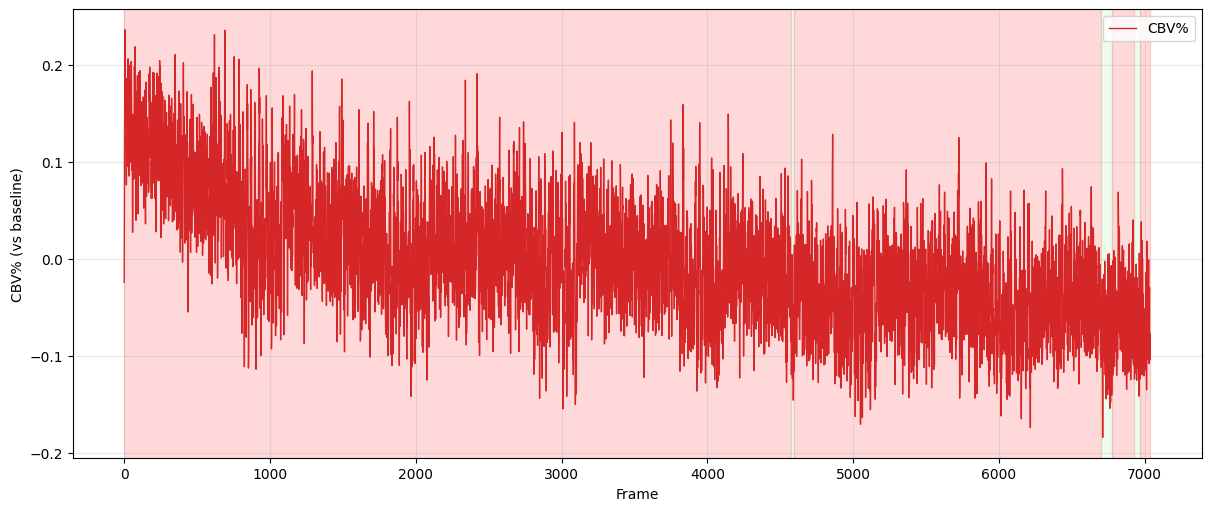

In [128]:
import matplotlib.pyplot as plt

# Boucle sur les 20 premiers éléments
for i in range(len(train_acqs.unique())):
    hf.plot_cbv_mean(train_acqs, train_images, train_labels, train_acqs.unique()[i])  # Appelle ta fonction
plt.show()

In [119]:
test_acqs.unique()

tensor([ 0,  1, 10])

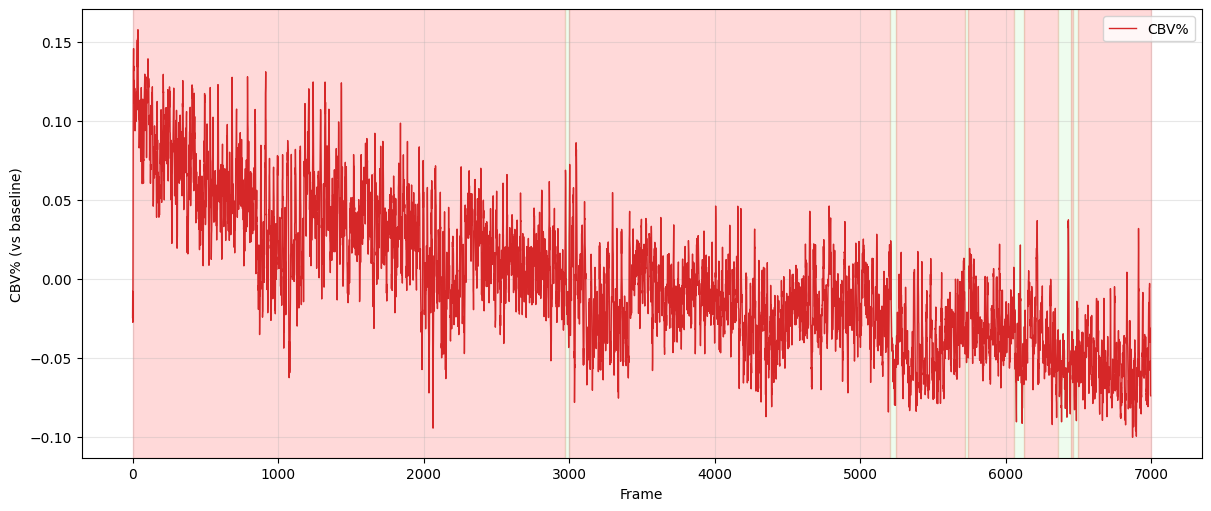

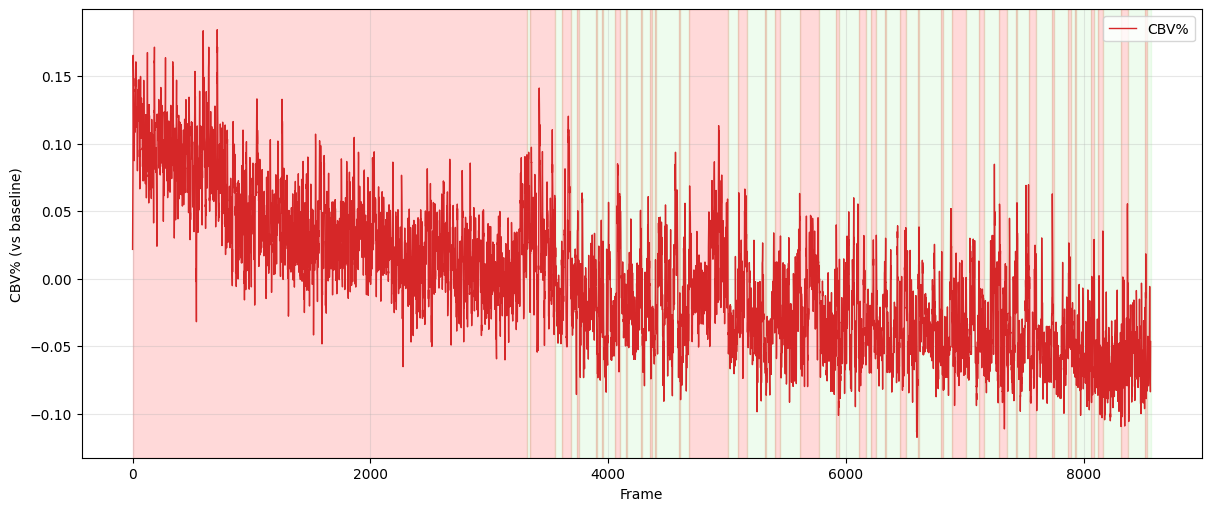

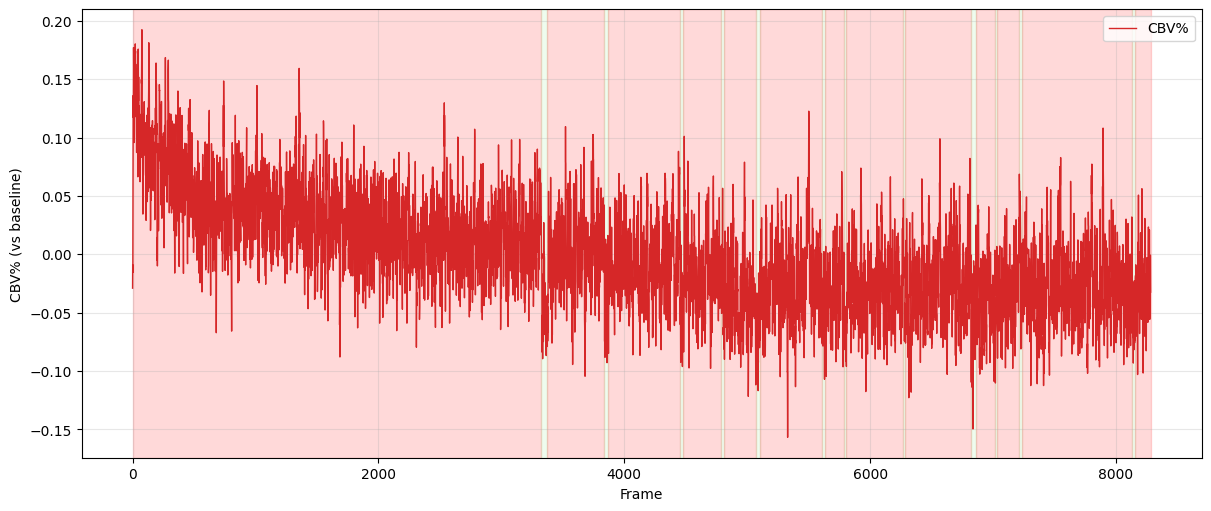

In [92]:
import matplotlib.pyplot as plt

# Boucle sur les 20 premiers éléments
for i in range(len(test_acqs.unique())):
    hf.plot_cbv_mean(test_acqs, test_images, test_labels, test_acqs.unique()[i])  # Appelle ta fonction
plt.show()

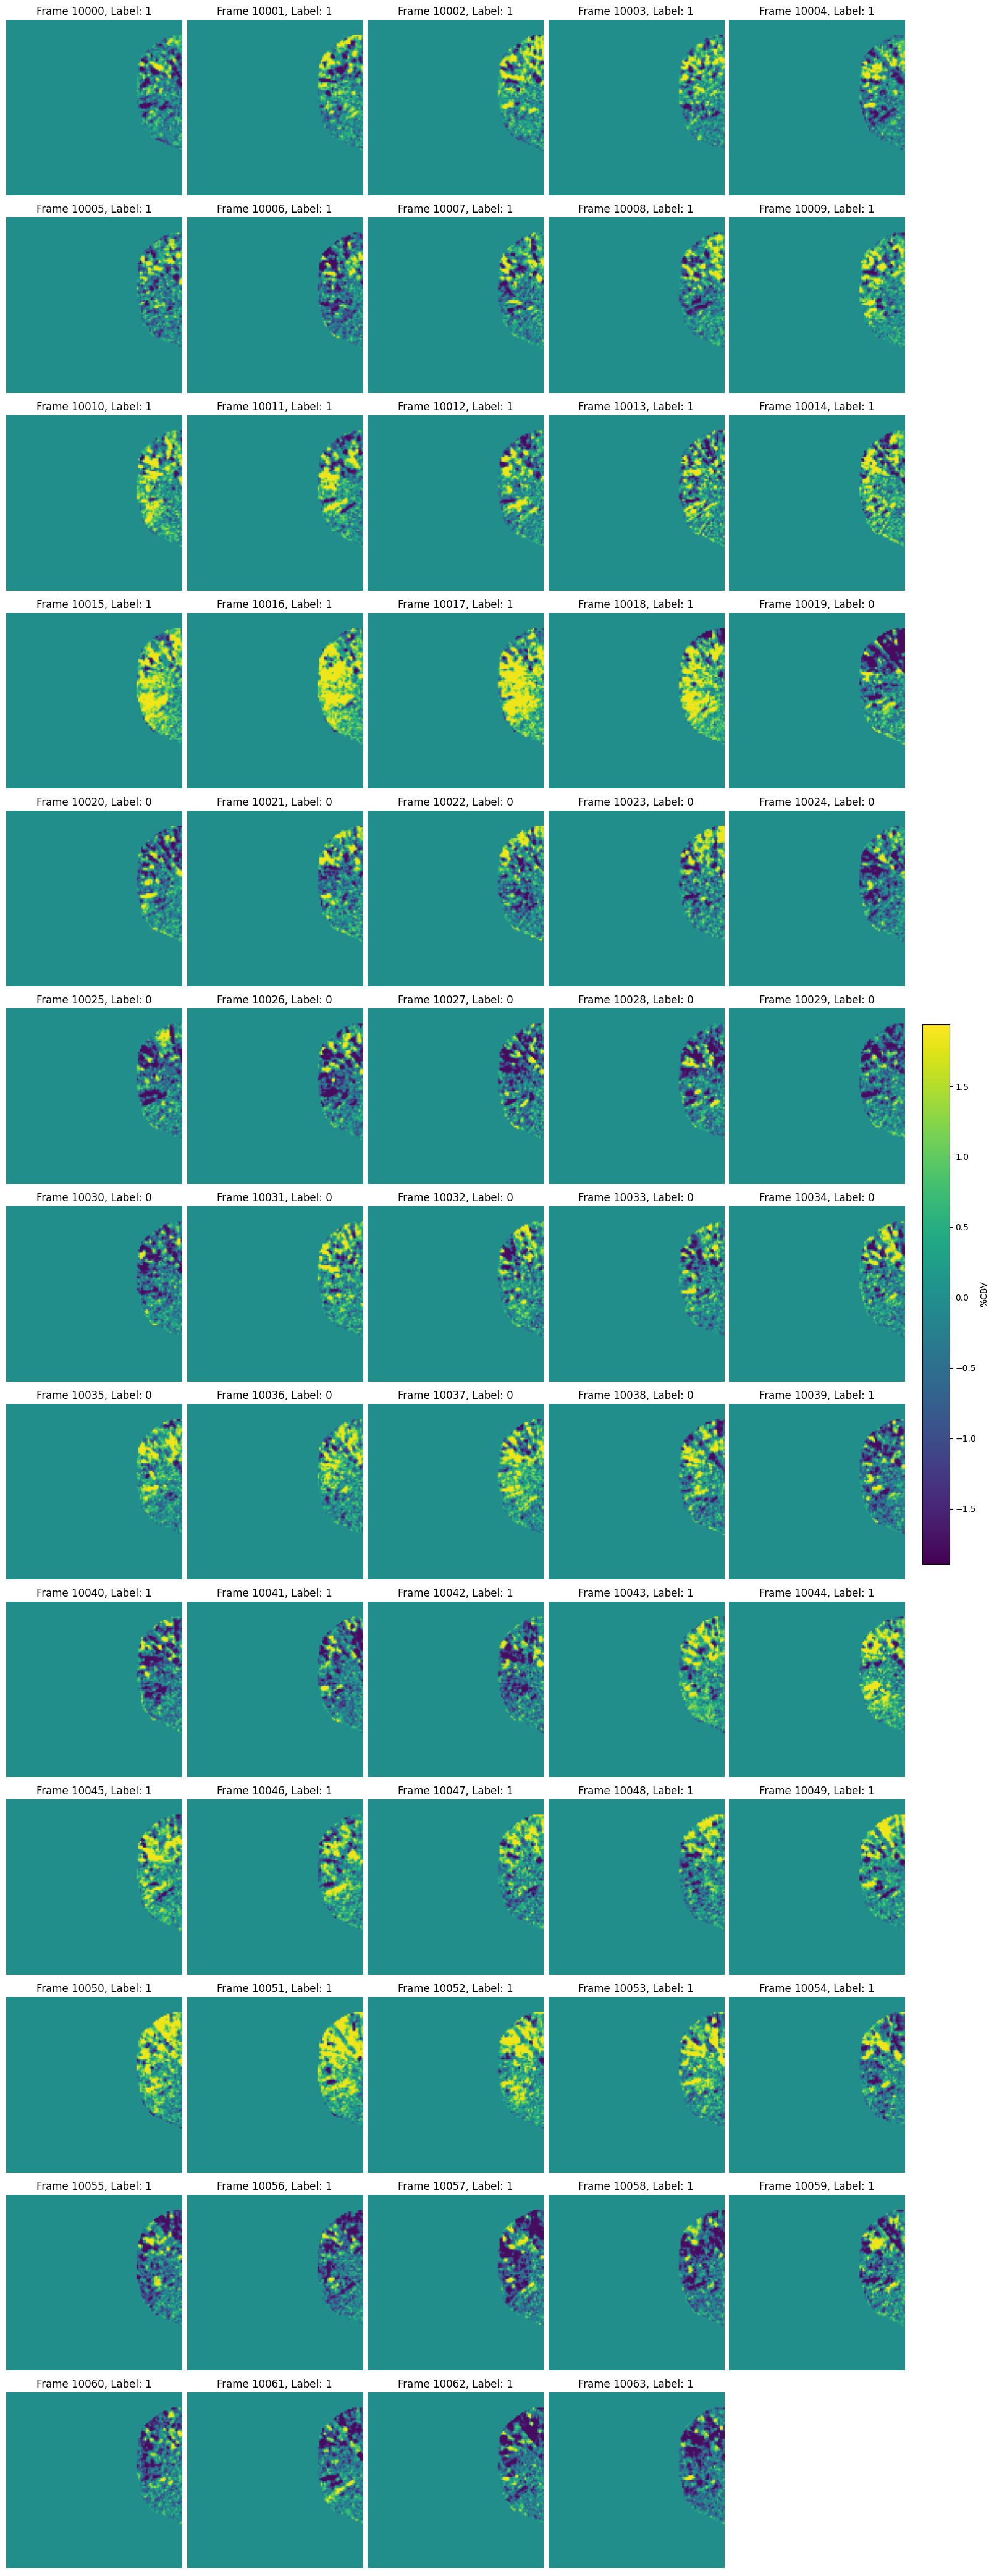

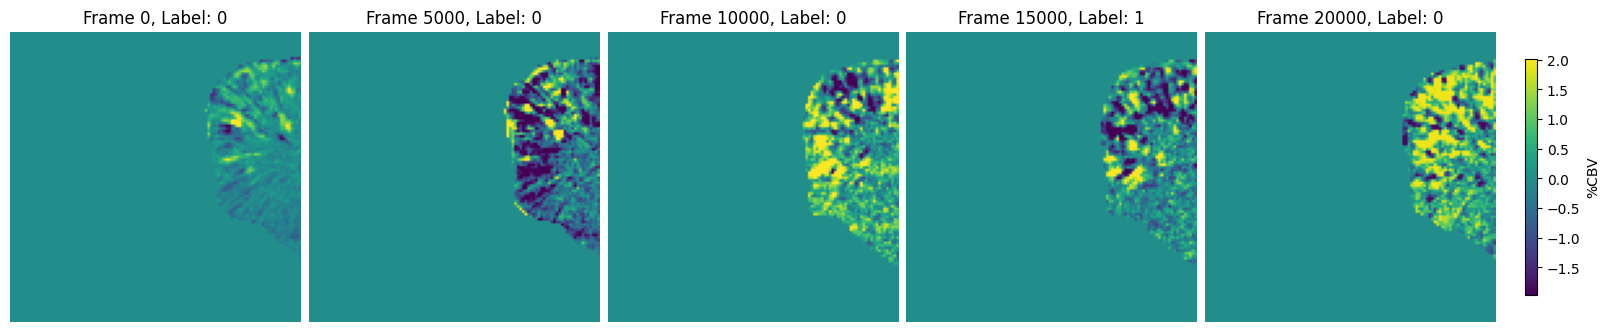

In [58]:
%matplotlib inline
hf.plot_cbv_samples (train_images, train_labels, start=10000, step=1, n=64, cmap='viridis', vmin=train_images.min(), vmax=train_images.max(), brain_roi=None)
hf.plot_cbv_samples (test_images, test_labels, start=0, step=5000, n=32, cmap='viridis', vmin=test_images.min(), vmax=test_images.max(), brain_roi=None)

In [42]:
# Dataset parameters
VERSION = 2.1
window_size = 16
stride = 1  # Overlapping windows for train/test since acquisitions are separated
image_size = 112
exclusion_distance = 0
batch_size = 16
num_workers = 0  # Adjust based on your system
num_channels = 1
num_labels = 2

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache()
print(f"Using device: {device}")

Using device: cuda


In [67]:
# Dataset class with train/test mode
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import numpy as np
import math

def gaussian_kernel(size, sigma):
    """Generate a Gaussian kernel."""
    x = torch.arange(-size // 2 + 1, size // 2 + 1)
    y = x
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

class GaussianNoise:
    """Add Gaussian noise to the tensor."""
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

class FilteredFUSWindowDataset(Dataset):
    def __init__(self, data_tensor, labels_tensor, window_size=8, stride=9, image_size=112, mode='train'):
        """
        Custom Dataset for sliding windows of FUS frames with cropping and normalization.
        For 'train' mode: Excludes windows that overlap with exclusion_distance frames before/after a state transition (0 to 1 or 1 to 0), and applies data augmentation.
        For 'test' mode: Includes all windows, no exclusion, no augmentation.
        
        Args:
            data_tensor (torch.Tensor): Shape [N, 1, H, W] (e.g., [6000, 1, 112, 112]).
            labels_tensor (torch.Tensor): Shape [N] with labels (0, 1). Assumes -1 already excluded.
            window_size (int): Number of frames per window (e.g., 8).
            stride (int): Step size for sliding window (e.g., 9 for non-overlapping with small gap).
            image_size (int): Target square size for frames (e.g., 112).
            exclusion_distance (int): Frames before/after transitions to exclude in train mode (default 50).
            mode (str): 'train' or 'test' to control exclusion and augmentation.
        """
        assert data_tensor.shape[0] == labels_tensor.shape[0], "Data and labels length mismatch"
        assert window_size > 0, "Window size must be positive"
        assert mode in ['train', 'test'], "Mode must be 'train' or 'test'"
        
        self.data = data_tensor
        self.labels = labels_tensor
        self.window_size = window_size
        self.stride = stride
        self.image_size = image_size
        self.mode = mode
        
        self.transform = T.Compose([
            T.Resize((image_size, image_size))  # Ensure square (redundant if already sized)
        ])
        '''
         # Find potential end indices (where label != -1, if any remain)
        potential_end_indices = []
        for i in range(window_size - 1, len(self.labels), stride):
            if self.labels[i] != -1:  # Skip -1 if present
                potential_end_indices.append(i)
                
        # Build valid indices, skipping excluded zones
        self.valid_indices = []
        for i in range(window_size - 1, len(self.labels), stride):
            if self.labels[i] != -1:  # Assume -1 already filtered out in preprocessing
                self.valid_indices.append(i)

        # Group potential end indices by label of end frame
        end_labels = self.labels[potential_end_indices].cpu().numpy()
        idx_0 = np.array(potential_end_indices)[end_labels == 0]
        idx_1 = np.array(potential_end_indices)[end_labels == 1]
        
        num_0 = len(idx_0)
        num_1 = len(idx_1)
        print(f"Before balancing: Work (0): {num_0} windows, Pause (1): {num_1} windows")
        
        np.random.seed(5)
        # Downsample majority to match minority
        min_count = min(num_0, num_1)
        if num_0 > min_count:
            idx_0 = np.random.choice(idx_0, min_count, replace=False)
        if num_1 > min_count:
            idx_1 = np.random.choice(idx_1, min_count, replace=False)
        
        # Combine and sort balanced indices (maintain original order for sequential access)
        self.valid_indices = sorted(np.concatenate([idx_0, idx_1]))
        print(f"After balancing: Total windows: {len(self.valid_indices)}")
        '''
        # Build valid indices, skipping excluded zones
        self.valid_indices = []
        for i in range(window_size - 1, len(self.labels), stride):
            if self.labels[i] != -1:  # Assume -1 already filtered out in preprocessing
                self.valid_indices.append(i)
        
        if len(self.valid_indices) == 0:
            print("Warning: No valid windows found. Check labels or window_size.")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        try:
            end_idx = self.valid_indices[idx]
            start_idx = end_idx - self.window_size + 1
            if start_idx < 0 or end_idx >= len(self.data):
                raise IndexError(f"Invalid window range: [{start_idx}:{end_idx + 1}]")
            
            window = self.data[start_idx:end_idx + 1]  # [T, 1, H, W]
            H, W = window.shape[-2:]
            
            # Apply base transform (resize if needed)
            window = torch.stack([self.transform(frame) for frame in window])  # [T, 1, 112, 112]
            
            if self.mode == 'train':
                # Data augmentation: translation/rotation/scale jitter (affine), elastic morph, gaussian noise
                # Apply same affine and elastic to all frames for temporal consistency
                
                # 1. Random Affine
                affine = T.RandomAffine(degrees=30, translate=(0.2, 0.2), scale=(0.8, 1.2))
                angle, translations, scale, shear = affine.get_params(
                    affine.degrees, affine.translate, affine.scale, affine.shear, (self.image_size, self.image_size)
                )
                for t in range(window.size(0)):
                    window[t] = TF.affine(
                        window[t],
                        angle=angle,
                        translate=translations,
                        scale=scale,
                        shear=shear,
                        interpolation=TF.InterpolationMode.BILINEAR,
                        fill=0
                    )
                
                # 2. Elastic deformation
                alpha = 50.0  # Intensity
                sigma = 5.0   # Smoothing
                filter_size = max(5, math.ceil(3 * sigma))
                kernel = gaussian_kernel(filter_size, sigma).unsqueeze(0).unsqueeze(0).to(window.device)  # [1, 1, fs, fs]
                padding = filter_size // 2
                
                dx = (torch.rand(1, 1, H, W, device=window.device) * 2 - 1)
                dy = (torch.rand(1, 1, H, W, device=window.device) * 2 - 1)
                
                dx = F.conv2d(dx, kernel, padding=padding) * alpha
                dy = F.conv2d(dy, kernel, padding=padding) * alpha
                
                dx = dx.squeeze()  # [H, W]
                dy = dy.squeeze()  # [H, W]
                
                norm_dx = dx * 2 / W
                norm_dy = dy * 2 / H
                
                x_coords = torch.linspace(-1, 1, W, device=window.device)
                y_coords = torch.linspace(-1, 1, H, device=window.device)
                yy, xx = torch.meshgrid(y_coords, x_coords, indexing='ij')  # [H, W]
                
                grid = torch.stack([xx + norm_dx, yy + norm_dy], dim=-1).unsqueeze(0)  # [1, H, W, 2]
                
                for t in range(window.size(0)):
                    frame = window[t].unsqueeze(0)  # [1, 1, H, W]
                    warped = F.grid_sample(frame, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
                    window[t] = warped.squeeze(0)
                
                # 3. Gaussian noise (applied independently per frame)
                noise = GaussianNoise(std=0.01)
                window = noise(window)
            
            # Verify window shape
            if window.shape[0] != self.window_size:
                raise ValueError(f"Expected {self.window_size} frames, got {window.shape[0]}")
            
            label = self.labels[end_idx]
            return window, label
        except Exception as e:
            print(f"Error in __getitem__ at idx {idx}, end_idx {end_idx}: {e}")
            raise

In [72]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import numpy as np
import math


def gaussian_kernel(size, sigma):
    """Generate a Gaussian kernel."""
    x = torch.arange(-size // 2 + 1, size // 2 + 1, dtype=torch.float32)  # Ensure float32
    y = x
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel
    
class GaussianNoise:
    """Add Gaussian noise to the tensor."""
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

class FilteredFUSWindowDataset(Dataset):
    def __init__(self, data_tensor, labels_tensor, window_size=8, stride=1, image_size=112, mode='train'):
        """
        Custom Dataset for sliding windows of FUS frames with cropping and normalization.
        For 'train' mode: Balances windows between labels 0 and 1 by downsampling majority class, and applies data augmentation.
        For 'test' mode: Includes all windows, no balancing, no augmentation.
        
        Args:
            data_tensor (torch.Tensor): Shape [N, 1, H, W] (e.g., [6000, 1, 112, 112]).
            labels_tensor (torch.Tensor): Shape [N] with labels (0, 1). Assumes -1 already excluded.
            window_size (int): Number of frames per window (e.g., 8).
            stride (int): Step size for sliding window (e.g., 9 for non-overlapping with small gap).
            image_size (int): Target square size for frames (e.g., 112).
            mode (str): 'train' or 'test' to control balancing and augmentation.
        """
        assert data_tensor.shape[0] == labels_tensor.shape[0], "Data and labels length mismatch"
        assert window_size > 0, "Window size must be positive"
        assert mode in ['train', 'test'], "Mode must be 'train' or 'test'"
        
        self.data = data_tensor
        self.labels = labels_tensor
        self.window_size = window_size
        self.stride = stride
        self.image_size = image_size
        self.mode = mode
        
        self.transform = T.Compose([
            T.Resize((image_size, image_size))  # Ensure square (redundant if already sized)
        ])

        # Build valid indices, skipping excluded zones
        self.valid_indices = []
        for i in range(window_size - 1, len(self.labels), stride):
            if self.labels[i] != -1:  # Assume -1 already filtered out in preprocessing
                self.valid_indices.append(i)

        if len(self.valid_indices) == 0:
            print("Warning: No valid windows found. Check labels or window_size.")
        
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        try:
            end_idx = self.valid_indices[idx]
            start_idx = end_idx - self.window_size + 1
            if start_idx < 0 or end_idx >= len(self.data):
                raise IndexError(f"Invalid window range: [{start_idx}:{end_idx + 1}]")
            
            window = self.data[start_idx:end_idx + 1]  # [T, 1, H, W]
            H, W = window.shape[-2:]
            window = torch.stack([self.transform(frame) for frame in window])  # [T, 1, 112, 112]
            
            # Verify window shape
            if window.shape[0] != self.window_size:
                raise ValueError(f"Expected {self.window_size} frames, got {window.shape[0]}")
                
            # === DATA AUGMENTATION (ONLY IN TRAIN MODE) ===
            if self.mode == 'train':
                # 1. Random Affine (same transformation for all frames)
                affine = T.RandomAffine(degrees=30, translate=(0.2, 0.2), scale=(0.8, 1.2))
                angle, translations, scale, shear = affine.get_params(
                    affine.degrees, affine.translate, affine.scale, affine.shear,
                    (self.image_size, self.image_size)
                )
                for t in range(window.size(0)):
                    window[t] = TF.affine(
                        window[t], angle=angle, translate=translations,
                        scale=scale, shear=shear,
                        interpolation=TF.InterpolationMode.BILINEAR, fill=0
                    )

                # 2. Elastic deformation (same deformation for all frames)
                alpha = 50.0
                sigma = 5.0
                filter_size = max(5, math.ceil(3 * sigma))
                kernel = gaussian_kernel(filter_size, sigma).unsqueeze(0).unsqueeze(0).to(window.device)
                padding = filter_size // 2

                dx = (torch.rand(1, 1, H, W, device=window.device, dtype=torch.float32) * 2 - 1)
                dy = (torch.rand(1, 1, H, W, device=window.device, dtype=torch.float32) * 2 - 1)

                dx = F.conv2d(dx, kernel, padding=padding) * alpha
                dy = F.conv2d(dy, kernel, padding=padding) * alpha

                dx = dx.squeeze()
                dy = dy.squeeze()

                norm_dx = dx * 2 / W
                norm_dy = dy * 2 / H

                x_coords = torch.linspace(-1, 1, W, device=window.device, dtype=torch.float32)
                y_coords = torch.linspace(-1, 1, H, device=window.device, dtype=torch.float32)
                yy, xx = torch.meshgrid(y_coords, x_coords, indexing='ij')

                grid = torch.stack([xx + norm_dx, yy + norm_dy], dim=-1).unsqueeze(0)  # [1, H, W, 2]
                  
                for t in range(window.size(0)):
                    frame = window[t].unsqueeze(0)  # [1, 1, H, W]
                    # print('frame.shape', frame.shape, 'grid.shape', grid.shape)
                    warped = F.grid_sample(
                        frame.float(), grid.float(), mode='bilinear',
                        padding_mode='zeros', align_corners=True
                    )
                    window[t] = warped.squeeze(0)

                # 3. Gaussian noise (independent per frame)
                noise = GaussianNoise(std=0.05)
                window = noise(window)
            
            
            label = self.labels[end_idx]
            return window, label
        except Exception as e:
            print(f"Error in __getitem__ at idx {idx}, end_idx {end_idx}: {e}")
            raise

In [68]:
# Create datasets
train_dataset = FilteredFUSWindowDataset(
    data_tensor=train_images,
    labels_tensor=train_labels,
    window_size=window_size,
    stride=1,
    image_size=image_size,
    mode='train'
)

test_dataset = FilteredFUSWindowDataset(
    data_tensor=test_images,
    labels_tensor=test_labels,
    window_size=window_size,
    stride=stride,
    image_size=image_size,
    mode='test'
)

print(f"Train dataset size: {len(train_dataset)} windows")
print(f"Test dataset size: {len(test_dataset)} windows")

Train dataset size: 63074 windows
Test dataset size: 23828 windows


In [ ]:
# Dataset class with new baseline channel
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import numpy as np
import math


def gaussian_kernel(size, sigma):
    """Generate a Gaussian kernel."""
    x = torch.arange(-size // 2 + 1, size // 2 + 1, dtype=torch.float32)
    y = x
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel


class GaussianNoise:
    """Add Gaussian noise to the tensor."""
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean


class FilteredFUSWindowDataset(Dataset):
    def __init__(self, data_tensor, labels_tensor, baseline_tensor=None,
                 window_size=8, stride=1, image_size=112, mode='train'):
        """
        Dataset for FUS frame windows with optional baseline channel.
        If baseline_tensor is provided, it's concatenated as a second channel.
        
        Args:
            data_tensor (torch.Tensor): [N, 1, H, W]
            labels_tensor (torch.Tensor): [N]
            baseline_tensor (torch.Tensor): (optional) [N, 1, H, W] reference channel
            window_size (int): number of frames per window
            stride (int): window stride
            image_size (int): output size (H=W=image_size)
            mode (str): 'train' or 'test'
        """
        assert data_tensor.shape[0] == labels_tensor.shape[0], "Data and labels length mismatch"
        if baseline_tensor is not None:
            assert baseline_tensor.shape == data_tensor.shape, "Baseline and data shapes must match"

        self.data = data_tensor
        self.labels = labels_tensor
        self.baseline = baseline_tensor
        self.window_size = window_size
        self.stride = stride
        self.image_size = image_size
        self.mode = mode

        self.transform = T.Compose([
            T.Resize((image_size, image_size))
        ])

        # Build valid indices
        self.valid_indices = [
            i for i in range(window_size - 1, len(self.labels), stride)
            if self.labels[i] != -1
        ]
        if len(self.valid_indices) == 0:
            print("Warning: No valid windows found. Check labels or window_size.")

    def __len__(self):
        return len(self.valid_indices)

    def _augment_window(self, window):
        """
        Apply augmentations (affine, elastic, noise) to the given dynamic window.
        """
        H, W = window.shape[-2:]

        # ----- 1. Random Affine -----
        affine = T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05))
        angle, translations, scale, shear = affine.get_params(
            affine.degrees, affine.translate, affine.scale, affine.shear,
            (self.image_size, self.image_size)
        )

        for t in range(window.size(0)):
            window[t] = TF.affine(
                window[t], angle=angle, translate=translations,
                scale=scale, shear=shear,
                interpolation=TF.InterpolationMode.BILINEAR, fill=0
            )
        # ----- 3. Gaussian Noise -----
        noise = GaussianNoise(std=0.01)
        window = noise(window)
        
        return window

    def __getitem__(self, idx):
        try:
            end_idx = self.valid_indices[idx]
            start_idx = end_idx - self.window_size + 1
            if start_idx < 0 or end_idx >= len(self.data):
                raise IndexError(f"Invalid window range: [{start_idx}:{end_idx+1}]")

            # ---- Dynamic frames ----
            window_data = self.data[start_idx:end_idx + 1]
            window_data = torch.stack([self.transform(frame) for frame in window_data])

            # ---- Baseline frames ----
            if self.baseline is not None:
                window_base = self.baseline[start_idx:end_idx + 1]
                window_base = torch.stack([self.transform(frame) for frame in window_base])
            else:
                window_base = None

            # ---- Data augmentation ----
            if self.mode == 'train':
                window_data = self._augment_window(window_data)
                # baseline is left unchanged (only mild noise could be added if desired)

            # ---- Combine channels ----
            if window_base is not None:
                window_data = torch.cat([window_data, window_base], dim=1)  # [T, 2, H, W]

            label = self.labels[end_idx]
            return window_data, label

        except Exception as e:
            print(f"Error in __getitem__ at idx {idx}, end_idx {end_idx}: {e}")
            raise

In [55]:
train_dataset = FilteredFUSWindowDataset(
    data_tensor=train_images,
    labels_tensor=train_labels,
    baseline_tensor=train_baseline_expanded,
    window_size=16,
    stride=1,
    mode='train'
)

test_dataset = FilteredFUSWindowDataset(
    data_tensor=test_images,
    labels_tensor=test_labels,
    baseline_tensor=test_baseline_expanded,
    window_size=16,
    stride=1,
    mode='test'
)

In [89]:
import torch
import matplotlib.pyplot as plt

# Pick your dataset
dataset = train_dataset  # or test_dataset

# Get one example window
window, label = dataset[0]            # window: [T, 2, H, W]
T, C, H, W = window.shape
print(f"Window shape: {window.shape}, Label: {label}")

# Pick a frame in the temporal window (e.g. the middle one)
mid_frame = T // 2
dynamic_frame = window[mid_frame, 0].cpu().numpy()
baseline_frame = window[mid_frame, 1].cpu().numpy()

# Normalize to [0,1] for display
def normalize(img):
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img

dynamic_frame = normalize(dynamic_frame)
baseline_frame = normalize(baseline_frame)

# ---- Show dynamic vs baseline ----
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(dynamic_frame, cmap='gray')
axes[0].set_title(f"Dynamic Frame (t={mid_frame})")
axes[0].axis("off")

axes[1].imshow(baseline_frame, cmap='gray')
axes[1].set_title("Baseline Frame (context)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ---- Optional: preview all dynamic frames ----
fig, axes = plt.subplots(2, T//2, figsize=(3*T//2, 4))
for t in range(T):
    r, c = divmod(t, T//2)
    axes[r, c].imshow(normalize(window[t, 0].cpu().numpy()), cmap='gray')
    axes[r, c].set_title(f"t={t}")
    axes[r, c].axis('off')
plt.suptitle("Dynamic Channel Sequence", y=1.05)
plt.tight_layout()
plt.show()

Window shape: torch.Size([16, 1, 112, 112]), Label: 0


IndexError: index 1 is out of bounds for dimension 1 with size 1

In [32]:
def compute_label_distribution(dataset):
    """
    Compute label counts from the dataset's valid windows.
    """
    if len(dataset.valid_indices) == 0:
        return {label: 0 for label in range(num_labels)}
    
    valid_labels = dataset.labels[dataset.valid_indices].numpy()  # Convert to numpy for unique
    unique, counts = np.unique(valid_labels, return_counts=True)
    dist = dict(zip(unique, counts))
    
    # Fill missing labels with 0
    for label in range(num_labels):
        if label not in dist:
            dist[label] = 0
    
    return dist

# Compute distributions
train_dist = compute_label_distribution(train_dataset)
test_dist = compute_label_distribution(test_dataset)

# Print distributions
print("Train Dataset Label Distribution:")
for label, count in train_dist.items():
    print(f"Label {label}: {count} ({count / len(train_dataset) * 100:.2f}%)" if len(train_dataset) > 0 else f"Label {label}: 0 (0.00%)")

print("\nTest Dataset Label Distribution:")
for label, count in test_dist.items():
    print(f"Label {label}: {count} ({count / len(test_dataset) * 100:.2f}%)" if len(test_dataset) > 0 else f"Label {label}: 0 (0.00%)")

# Compute class weights based on train distribution (inverse frequency)
total_train_samples = len(train_dataset)
class_weights = []
for label in range(num_labels):
    count = train_dist.get(label, 0)
    if count > 0:
        weight = total_train_samples / (num_labels * count)
    else:
        weight = 0.0  # Or handle as needed (e.g., 1.0 if no samples)
    class_weights.append(weight)

weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print("\nClass Weights Tensor for CrossEntropyLoss (based on train dist):")
print(weights_tensor)

Train Dataset Label Distribution:
Label 0: 117567 (87.40%)
Label 1: 16954 (12.60%)

Test Dataset Label Distribution:
Label 0: 29953 (89.63%)
Label 1: 3467 (10.37%)

Class Weights Tensor for CrossEntropyLoss (based on train dist):
tensor([0.5721, 3.9672])


In [160]:
len(train_dataset.labels)

134528

In [71]:
# Create DataLoaders
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=True  # Avoid partial batch issues
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # No shuffling for test
    num_workers=num_workers,
    pin_memory=True,
    drop_last=False  # Keep all test samples
)

print(f"Train DataLoader: {len(train_dataloader)} batches of size {batch_size}")
print(f"Test DataLoader: {len(test_dataloader)} batches of size {batch_size}")

Train DataLoader: 3942 batches of size 16
Test DataLoader: 1490 batches of size 16


In [21]:
pip install timm==1.0.9

Note: you may need to restart the kernel to use updated packages.


In [70]:
# Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=True  # Avoid partial batch issues
)

val_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # No shuffling for test
    num_workers=num_workers,
    pin_memory=True,
    drop_last=False  # Keep all test samples
)

print(f"Train DataLoader: {len(train_dataloader)} batches of size {batch_size}")
print(f"Test DataLoader: {len(test_dataloader)} batches of size {batch_size}")

Train DataLoader: 3942 batches of size 16
Test DataLoader: 1490 batches of size 16


In [67]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

class FUSSequenceClassifier(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=2, dropout=0.3, n_classes=2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # x: [B, T, 768]
        out, hn = self.gru(x)
        # Use last hidden state (bidirectional → concat forward/backward)
        hn = hn[-2:].transpose(0, 1).reshape(x.size(0), -1)  # [B, hidden*2]
        logits = self.classifier(hn)
        return logits

In [68]:
from tqdm import tqdm
# --- 3. Model + Training ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Working on device:', device)
model = FUSSequenceClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

def train_epoch(loader):
    model.train()
    total_loss = 0
    preds, trues = [], []
    for xb, yb in tqdm(loader):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(yb.cpu().numpy())
    acc = accuracy_score(trues, preds)
    return total_loss / len(loader), acc

def val_epoch(loader):
    model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            prob = torch.softmax(logits, 1)[:, 1]
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())
            probs.extend(prob.cpu().numpy())
    acc = accuracy_score(trues, preds)
    auc = roc_auc_score(trues, probs)
    return acc, auc

# --- 4. Train ---
for epoch in range(1, 31):
    tr_loss, tr_acc = train_epoch(train_loader)
    val_acc, val_auc = val_epoch(val_loader)
    print(f"Ep {epoch:02d} | Loss: {tr_loss:.4f} | Tr Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f} | AUC: {val_auc:.4f}")

Working on device: cuda


  0%|          | 6/4203 [00:46<9:02:33,  7.76s/it]


KeyboardInterrupt: 

In [ ]:
# Load and configurate VideoMAE-small - 2 CHANNELS VERS
# Load pre-trained model name (switch to small)
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from transformers import VideoMAEForVideoClassification, VideoMAEConfig

model_name = "MCG-NJU/videomae-small-finetuned-kinetics"

# Custom config for your FUS data
config = VideoMAEConfig.from_pretrained(model_name)
config.num_channels = num_channels  # Grayscale FUS data
config.image_size = image_size  # Your frame size
config.num_frames = window_size   # Your window size
config.num_labels = num_labels   # Work (0) vs Pause (1)
config.attention_dropout = 0.1  # Add dropout to attention weights
config.hidden_dropout = 0.1     # Add dropout in transformer blocks
config.classifier_dropout = 0.5 # Add dropout before classifier

# Initialize model with custom config
model = VideoMAEForVideoClassification(config)

# Load pre-trained weights and adapt for 1 channel
pretrained_model = VideoMAEForVideoClassification.from_pretrained(model_name)
pretrained_dict = pretrained_model.state_dict()

# Adapt patch embedding weights: Average over RGB channels
pretrained_embed_weight = pretrained_dict['videomae.embeddings.patch_embeddings.projection.weight']  # Smaller: [384, 3, 2, 16, 16]
mono_weight = pretrained_embed_weight.mean(dim=1, keepdim=True)
# make random init for second channel
noise = torch.zeros_like(mono_weight)
new_embed_weight = torch.cat([mono_weight, noise], dim=1)
pretrained_dict['videomae.embeddings.patch_embeddings.projection.weight'] = new_embed_weight

# Remove classifier weights (reinitialized for 2 classes)
del pretrained_dict['classifier.weight']
del pretrained_dict['classifier.bias']

# Load adapted weights
model.load_state_dict(pretrained_dict, strict=False)
model.to(device)
print("Small VideoMAE loaded with adapted weights")

Small VideoMAE loaded with adapted weights


In [45]:
# Load and configurate VideoMAE-small
# Load pre-trained model name (switch to small)
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from transformers import VideoMAEForVideoClassification, VideoMAEConfig

model_name = "MCG-NJU/videomae-small-finetuned-kinetics"

# Custom config for your FUS data
config = VideoMAEConfig.from_pretrained(model_name)
config.num_channels = num_channels  # Grayscale FUS data
config.image_size = image_size  # Your frame size
config.num_frames = window_size   # Your window size
config.num_labels = num_labels   # Work (0) vs Pause (1)
config.attention_dropout = 0.1  # Add dropout to attention weights
config.hidden_dropout = 0.1     # Add dropout in transformer blocks
config.classifier_dropout = 0.5 # Add dropout before classifier

# Initialize model with custom config
model = VideoMAEForVideoClassification(config)

# Load pre-trained weights and adapt for 1 channel
pretrained_model = VideoMAEForVideoClassification.from_pretrained(model_name)
pretrained_dict = pretrained_model.state_dict()

# Adapt patch embedding weights: Average over RGB channels
pretrained_embed_weight = pretrained_dict['videomae.embeddings.patch_embeddings.projection.weight']  # Smaller: [384, 3, 2, 16, 16]
new_embed_weight = pretrained_embed_weight.mean(dim=1, keepdim=True)  # [384, 1, 2, 16, 16]
pretrained_dict['videomae.embeddings.patch_embeddings.projection.weight'] = new_embed_weight


# Remove classifier weights (reinitialized for 2 classes)
del pretrained_dict['classifier.weight']
del pretrained_dict['classifier.bias']

# Load adapted weights
model.load_state_dict(pretrained_dict, strict=False)
model.to(device)
print("Small VideoMAE loaded with adapted weights")

Small VideoMAE loaded with adapted weights


In [72]:
# Dataset parameters
window_size = 16
stride = 1  # Overlapping windows for train/test since acquisitions are separated
image_size = 112
exclusion_distance = 50
batch_size = 16
num_workers = 0  # Adjust based on your system
num_channels = 1
num_labels = 2
num_epochs = 100

In [64]:
model_name = "MCG-NJU/videomae-small-finetuned-kinetics"

# Custom config for your FUS data
config = VideoMAEConfig.from_pretrained(model_name)
config.num_channels = num_channels  # Grayscale FUS data
config.image_size = image_size  # Your frame size
config.num_frames = window_size   # Your window size
config.num_labels = num_labels   # Work (0) vs Pause (1)
config.attention_dropout = 0.1  # Add dropout to attention weights
config.hidden_dropout = 0.1     # Add dropout in transformer blocks
config.classifier_dropout = 0.5 # Add dropout before classifier

# Initialize model with custom config
model = VideoMAEForVideoClassification(config)

# Load pre-trained weights and adapt for 1 channel
pretrained_model = VideoMAEForVideoClassification.from_pretrained(model_name)
pretrained_dict = pretrained_model.state_dict()

# Adapt patch embedding weights: Average over RGB channels
pretrained_embed_weight = pretrained_dict['videomae.embeddings.patch_embeddings.projection.weight']  # Smaller: [768, 3, 2, 16, 16]
new_embed_weight = pretrained_embed_weight.mean(dim=1, keepdim=True)  # [768, 1, 2, 16, 16]
pretrained_dict['videomae.embeddings.patch_embeddings.projection.weight'] = new_embed_weight

# Remove classifier weights (reinitialized for 2 classes)
del pretrained_dict['classifier.weight']
del pretrained_dict['classifier.bias']

# Load adapted weights
model.load_state_dict(pretrained_dict, strict=False)
model.to(device)
print("Small VideoMAE loaded with adapted weights")

Small VideoMAE loaded with adapted weights


In [65]:
model.load_state_dict(torch.load(r"C:\Users\leo.sperber\FUSclass\Results V1\masked test\fus_videomae_small_16_nohp_balanced_zscore_masked_STABLE_balance.pth"))

<All keys matched successfully>

In [73]:
# Logit per frame on sing acq in test
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming acq_dataset, acq_dataloader, acq_labels, model, device, and window_size are defined

model.eval()

# Collect logits and labels for all windows
all_logits_class1 = []
all_labels = []  # Window labels (last frame of window)

with torch.no_grad():
    for batch_windows, batch_labels in acq_dataloader:
        inputs = batch_windows.to(device)
        labels = batch_labels.cpu().numpy()

        outputs = model(pixel_values=inputs.float())
        logits = outputs.logits

        logits_class1 = logits[:, 1].cpu().numpy()

        all_logits_class1.extend(logits_class1)
        all_labels.extend(labels)

# Convert to numpy arrays
all_logits_class1 = np.array(all_logits_class1)
all_labels = np.array(all_labels)

# Frame indices are the end indices of each window
frame_indices = np.array(acq_dataset.valid_indices)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the raw logits for class 1
plt.plot(frame_indices, all_logits_class1, color='blue', label='Class 1 Logit', linewidth=1.5)

# Create background shading based on full acquisition labels
label_colors = {0: 'red', 1: 'green', -1: 'gray'}

# Find regions where labels change in full acq_labels
acq_labels_np = acq_labels.cpu().numpy() if isinstance(acq_labels, torch.Tensor) else np.array(acq_labels)
label_changes = np.where(acq_labels_np[:-1] != acq_labels_np[1:])[0] + 1
label_changes = np.concatenate([[0], label_changes, [len(acq_labels_np)]])

# Plot shaded regions over full frame range
for i in range(len(label_changes) - 1):
    start_idx = label_changes[i]
    end_idx = label_changes[i + 1] - 1 if label_changes[i + 1] < len(acq_labels_np) else len(acq_labels_np) - 1
    label = acq_labels_np[label_changes[i]]
    plt.axvspan(start_idx, end_idx, facecolor=label_colors.get(label, 'gray'), alpha=0.3, label=f'Label {label}' if i == 0 else None)

# Customize the plot
plt.xlabel('Frame Index')
plt.ylabel('Class 1 Logit')
plt.title(f'Model Predictions (Class 1 Logit) vs. Frame Index with True Label Shading - Acquisition {selected_acq_id}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Save and show the plot
plt.savefig(f"C:/Users/leo.sperber/FUSclass/Results-V0/{VERSION}/plots/prediction_per_frame_{window_size}f_acq{selected_acq_id}")
plt.show()

# Print some statistics for verification
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("Label distribution in test set:")
for label, count in zip(unique_labels, counts):
    percentage = count / len(all_labels) * 100
    print(f"Label {label}: {count} windows ({percentage:.2f}%)")

NameError: name 'acq_dataloader' is not defined

100%|██████████| 1490/1490 [03:51<00:00,  6.42it/s]



FINAL TEST RESULTS
Accuracy         : 0.8848
F1-Score         : 0.7195
Precision        : 0.6212
Recall (Sensitivity) : 0.8548
ROC-AUC          : 0.9387
PR-AUC           : 0.7738


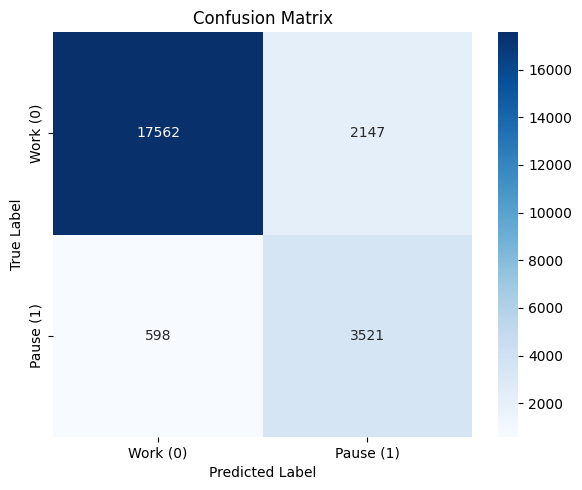

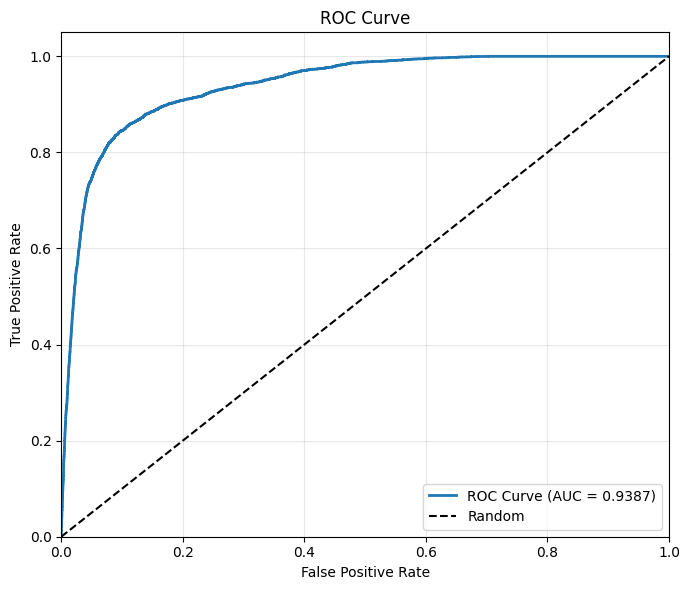

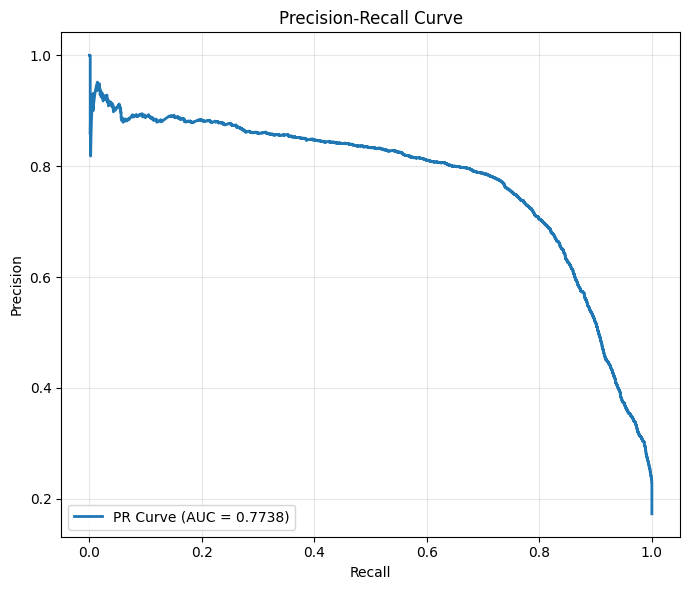

All plots saved: confusion_matrix.png, roc_curve.png, pr_curve.png


In [74]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import os


# ==================== EVALUATION ====================
all_preds = []
all_labels = []
all_probs = []  # for ROC, PR curves

with torch.no_grad():
    for batch_windows, batch_labels in tqdm(test_dataloader):
        inputs = batch_windows.to(device).float()
        labels = batch_labels.to(device, dtype=torch.long)
        outputs = model(pixel_values=inputs).logits
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_probs.extend(probabilities[:, 1].cpu().numpy())   # prob of class 1 (Pause)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to numpy
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# ==================== METRICS ====================
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  # sensitivity
roc_auc = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

print("\n" + "="*50)
print("FINAL TEST RESULTS")
print("="*50)
print(f"Accuracy         : {acc:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall (Sensitivity) : {recall:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"PR-AUC           : {pr_auc:.4f}")
print("="*50)

# ==================== PLOTS ====================

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Work (0)', 'Pause (1)'],
            yticklabels=['Work (0)', 'Pause (1)'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(rec, prec, label=f'PR Curve (AUC = {pr_auc:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=300)
plt.show()

print("All plots saved: confusion_matrix.png, roc_curve.png, pr_curve.png")

Found 37 valid transitions.
New transition windows tensor shape: torch.Size([37, 116, 1, 112, 112])


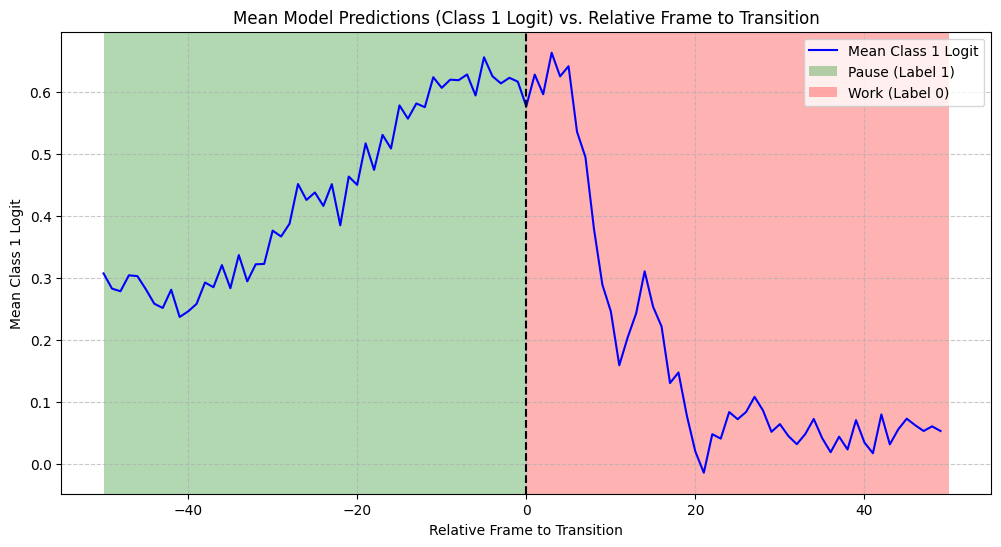

Mean logits statistics:
Mean logit (pause, -50 to 0): 0.4333
Mean logit (work, 0 to +50): 0.1721


In [ ]:
# Pause to work window and plot
import torch
import numpy as np

# Extract tensors from doppler_test_dataset
data_tensor = test_images # Shape: (N, 1, 112, 112)
labels_tensor = test_labels  # Shape: (N,)

# Parameters
min_state_length = 20
before_frames = 66
after_frames = 50
window_length = before_frames + after_frames

# Convert labels to NumPy for easier indexing
labels_np = labels_tensor.cpu().numpy()

# Find potential transition points: from 1 (pause) to 0 (work)
transitions = []
N = len(labels_np)
for i in range(1, N):
    if labels_np[i-1] == 1 and labels_np[i] == 0:
        # Check before: at least 50 consecutive 1's before i (i-51 to i-1 all 1)
        if i - min_state_length - 1 >= 0 and np.all(labels_np[i - min_state_length - 1:i - 1] == 1):
            # Check after: at least 50 consecutive 0's after i (i to i+49 all 0)
            if i + min_state_length <= N and np.all(labels_np[i:i + min_state_length] == 0):
                transitions.append(i)

print(f"Found {len(transitions)} valid transitions.")

# Create windows for each transition
windows = []
for trans_point in transitions:
    start_idx = trans_point - before_frames
    end_idx = trans_point + after_frames
    if start_idx >= 0 and end_idx <= N:
        window = data_tensor[start_idx:end_idx]
        windows.append(window)
    else:
        print(f"Skipping transition at {trans_point}: Insufficient frames around it.")

if windows:
    new_windows_tensor = torch.stack(windows)  # Shape: (K, window_length, 1, 112, 112)
    print(f"New transition windows tensor shape: {new_windows_tensor.shape}")
else:
    new_windows_tensor = torch.empty(0, window_length, 1, 112, 112)
    print("No valid transition windows found.")

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

model.eval()

# Assume model, device, new_window_tensor, WINDOW_SIZE, and other variables are defined
# new_window_tensor: [8, 72, 1, 112, 112] (8 transitions, each with 72 frames)

# Parameters
transition_point = 66 # Transition at frame 50 (0-based: frame 49 = last pause, 50 = first work)
relative_start = -50  # Relative to transition
relative_end = 50
relative_range = range(relative_start, relative_end)  # -50 to +50
num_transitions = new_windows_tensor.shape[0]  # 8

# Collect logits for class 1 across all transitions and relative positions
all_logits_class1 = np.zeros((num_transitions, len(relative_range)))  # [8, 101] for -50 to +50

with torch.no_grad():
    for trans_idx in range(num_transitions):
        transition_window = new_windows_tensor[trans_idx:trans_idx+1].to(device)  # [1, 72, 1, 112, 112]
        
        # Slide sub-windows of WINDOW_SIZE=16 over the 72-frame window
        # For each relative k, get sub-window ending at transition_point + k
        for k_idx, k in enumerate(relative_range):
            end_frame = transition_point + k
            start_frame = end_frame - window_size
            
            if start_frame < 0 or end_frame >= transition_window.shape[1]:
                print(f"Skipping invalid sub-window for trans {trans_idx}, relative {k}")
                print(f"  start_frame: {start_frame}, end_frame: {end_frame}")
                print(f"  window length: {transition_window.shape[1]}")
                continue
            
            sub_window = transition_window[:, start_frame:end_frame, :, :, :]  # [1, 16, 1, 112, 112]
            sub_window = sub_window.float()
            # Get model outputs
            outputs = model(pixel_values=sub_window).logits  # [1, 2]
            
            # Extract logit for class 1
            logit_class1 = outputs[0, 1].cpu().item()  # Raw score for class 1
            
            all_logits_class1[trans_idx, k_idx] = logit_class1

# Compute mean logits across transitions for each relative position
mean_logits_class1 = np.mean(all_logits_class1, axis=0)  # [101,]

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the mean logits for class 1
plt.plot(relative_range, mean_logits_class1, color='blue', label='Mean Class 1 Logit', linewidth=1.5)

# Create background shading for labels
# Pause (-50 to 0): green, Work (0 to +50): red
plt.axvspan(relative_start, 0, facecolor='green', alpha=0.3, label='Pause (Label 1)')
plt.axvspan(0, relative_end, facecolor='red', alpha=0.3, label='Work (Label 0)')

# Customize the plot
plt.xlabel('Relative Frame to Transition')
plt.ylabel('Mean Class 1 Logit')
plt.title('Mean Model Predictions (Class 1 Logit) vs. Relative Frame to Transition')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(0, color='black', linestyle='--', label='Transition Point')

# Show the plot
plt.show()

# Print some statistics for verification
print("Mean logits statistics:")
print(f"Mean logit (pause, -50 to 0): {np.mean(mean_logits_class1[:51]):.4f}")
print(f"Mean logit (work, 0 to +50): {np.mean(mean_logits_class1[51:]):.4f}")

Found 37 valid transitions.
New transition windows tensor shape: torch.Size([37, 116, 1, 112, 112])


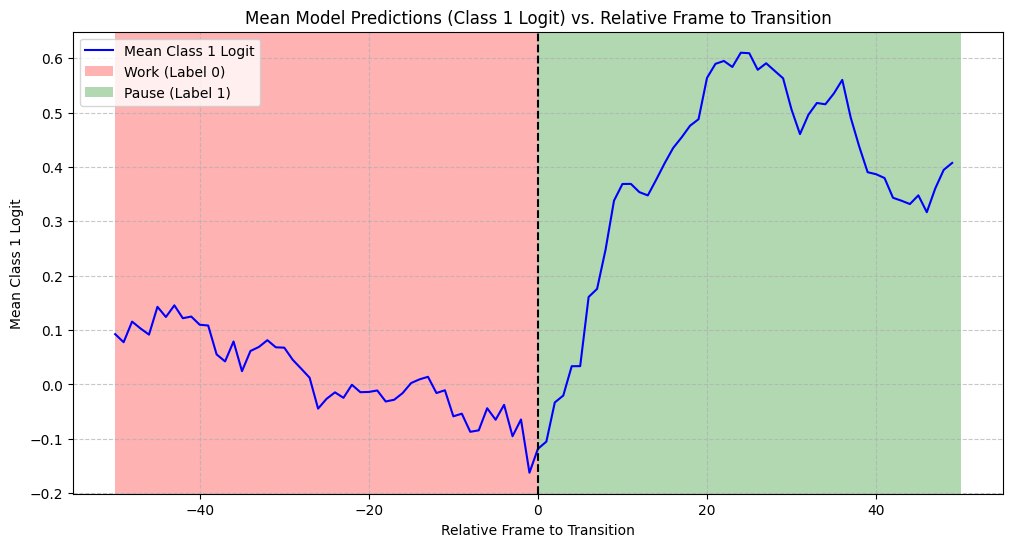

Mean logits statistics:
Mean logit (pause, -50 to 0): 0.0175
Mean logit (work, 0 to +50): 0.3935


In [86]:
# Pause to work window and plot
import torch
import numpy as np

# Extract tensors from doppler_test_dataset
data_tensor = test_images # Shape: (N, 1, 112, 112)
labels_tensor = test_labels  # Shape: (N,)

# Parameters
min_state_length = 20
before_frames = 66
after_frames = 50
window_length = before_frames + after_frames

# Convert labels to NumPy for easier indexing
labels_np = labels_tensor.cpu().numpy()

# Find potential transition points: from 1 (pause) to 0 (work)
transitions = []
N = len(labels_np)
for i in range(1, N):
    if labels_np[i-1] == 0 and labels_np[i] == 1:
        # Check before: at least 50 consecutive 1's before i (i-51 to i-1 all 1)
        if i - min_state_length - 1 >= 0 and np.all(labels_np[i - min_state_length - 1:i - 1] == 0):
            # Check after: at least 50 consecutive 0's after i (i to i+49 all 0)
            if i + min_state_length <= N and np.all(labels_np[i:i + min_state_length] == 1):
                transitions.append(i)

print(f"Found {len(transitions)} valid transitions.")

# Create windows for each transition
windows = []
for trans_point in transitions:
    start_idx = trans_point - before_frames
    end_idx = trans_point + after_frames
    if start_idx >= 0 and end_idx <= N:
        window = data_tensor[start_idx:end_idx]
        windows.append(window)
    else:
        print(f"Skipping transition at {trans_point}: Insufficient frames around it.")

if windows:
    new_windows_tensor = torch.stack(windows)  # Shape: (K, window_length, 1, 112, 112)
    print(f"New transition windows tensor shape: {new_windows_tensor.shape}")
else:
    new_windows_tensor = torch.empty(0, window_length, 1, 112, 112)
    print("No valid transition windows found.")

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

model.eval()

# Assume model, device, new_window_tensor, WINDOW_SIZE, and other variables are defined
# new_window_tensor: [8, 72, 1, 112, 112] (8 transitions, each with 72 frames)

# Parameters
transition_point = 66 # Transition at frame 50 (0-based: frame 49 = last pause, 50 = first work)
relative_start = -50  # Relative to transition
relative_end = 50
relative_range = range(relative_start, relative_end)  # -50 to +50
num_transitions = new_windows_tensor.shape[0]  # 8

# Collect logits for class 1 across all transitions and relative positions
all_logits_class1 = np.zeros((num_transitions, len(relative_range)))  # [8, 101] for -50 to +50

with torch.no_grad():
    for trans_idx in range(num_transitions):
        transition_window = new_windows_tensor[trans_idx:trans_idx+1].to(device)  # [1, 72, 1, 112, 112]
        
        # Slide sub-windows of WINDOW_SIZE=16 over the 72-frame window
        # For each relative k, get sub-window ending at transition_point + k
        for k_idx, k in enumerate(relative_range):
            end_frame = transition_point + k
            start_frame = end_frame - window_size
            
            if start_frame < 0 or end_frame >= transition_window.shape[1]:
                print(f"Skipping invalid sub-window for trans {trans_idx}, relative {k}")
                print(f"  start_frame: {start_frame}, end_frame: {end_frame}")
                print(f"  window length: {transition_window.shape[1]}")
                continue
            
            sub_window = transition_window[:, start_frame:end_frame, :, :, :]  # [1, 16, 1, 112, 112]
            sub_window = sub_window.float()
            # Get model outputs
            outputs = model(pixel_values=sub_window).logits  # [1, 2]
            
            # Extract logit for class 1
            logit_class1 = outputs[0, 1].cpu().item()  # Raw score for class 1
            
            all_logits_class1[trans_idx, k_idx] = logit_class1

# Compute mean logits across transitions for each relative position
mean_logits_class1 = np.mean(all_logits_class1, axis=0)  # [101,]

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the mean logits for class 1
plt.plot(relative_range, mean_logits_class1, color='blue', label='Mean Class 1 Logit', linewidth=1.5)

# Create background shading for labels
# Pause (-50 to 0): green, Work (0 to +50): red
plt.axvspan(relative_start, 0, facecolor='red', alpha=0.3, label='Work (Label 0)')
plt.axvspan(0, relative_end, facecolor='green', alpha=0.3, label='Pause (Label 1)')

# Customize the plot
plt.xlabel('Relative Frame to Transition')
plt.ylabel('Mean Class 1 Logit')
plt.title('Mean Model Predictions (Class 1 Logit) vs. Relative Frame to Transition')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(0, color='black', linestyle='--', label='Transition Point')

# Show the plot
plt.show()

# Print some statistics for verification
print("Mean logits statistics:")
print(f"Mean logit (pause, -50 to 0): {np.mean(mean_logits_class1[:51]):.4f}")
print(f"Mean logit (work, 0 to +50): {np.mean(mean_logits_class1[51:]):.4f}")

Plotting for acquisition 0 which has transitions.


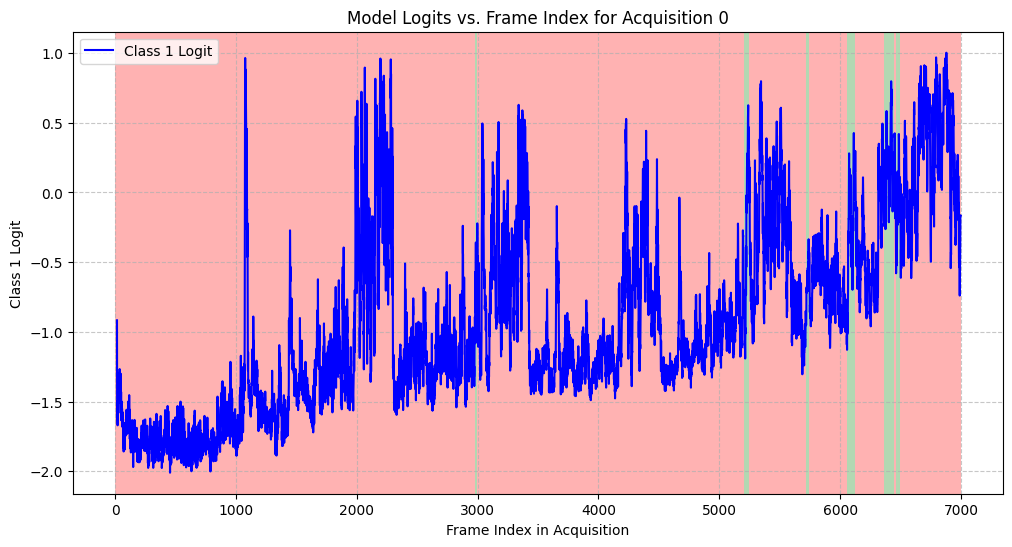

Plotting for acquisition 1 which has transitions.


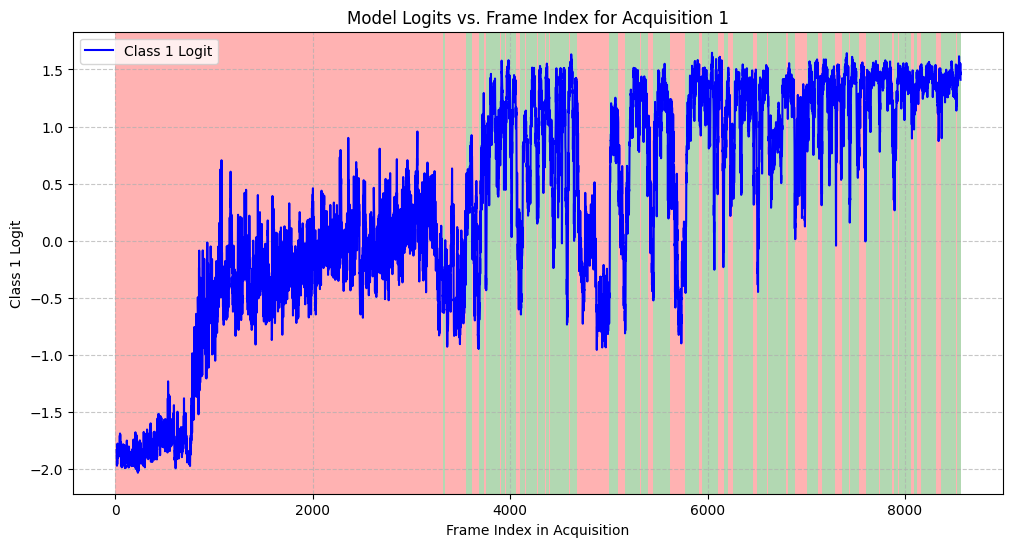

Plotting for acquisition 10 which has transitions.


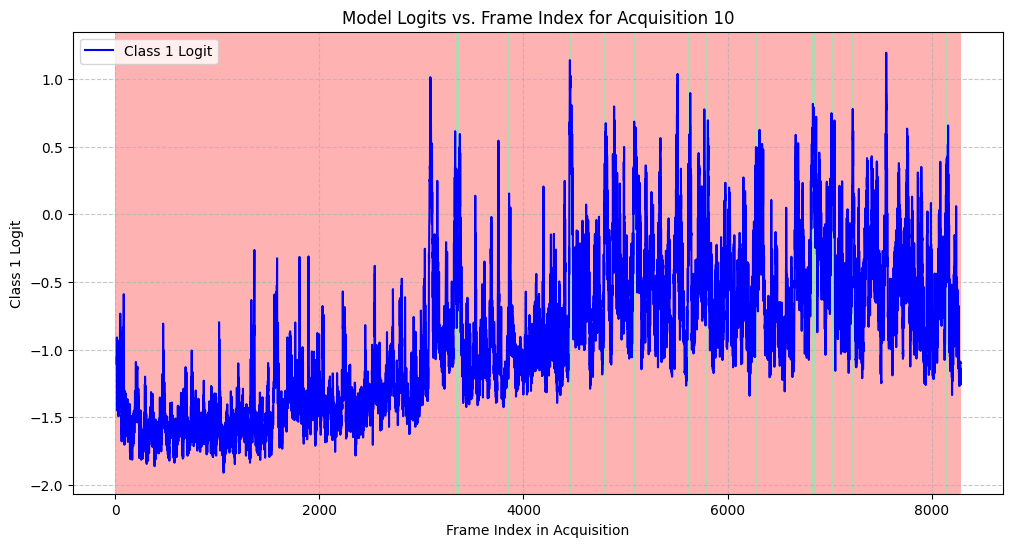

No acquisitions with transitions found; plotting the first one.


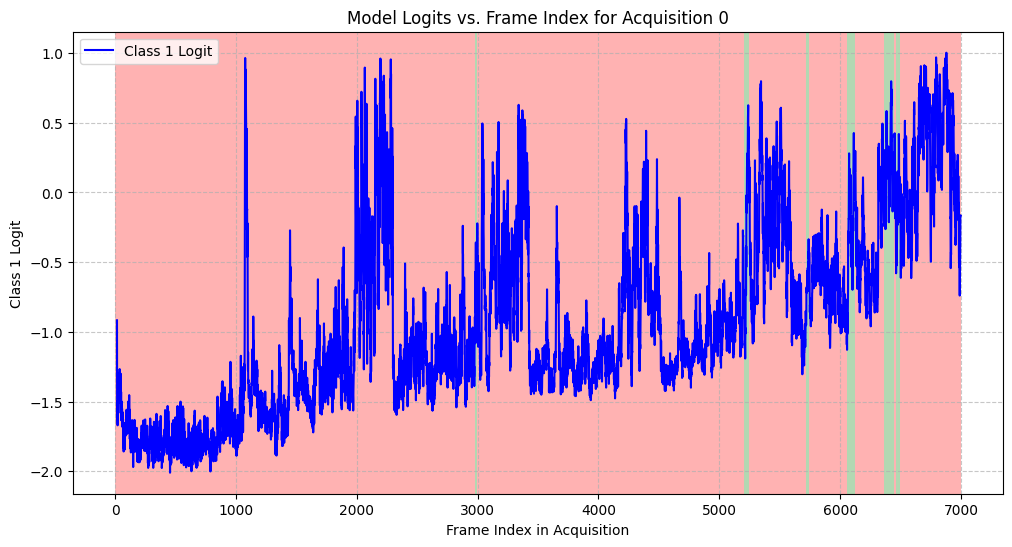

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assume model, device, test_images, test_labels, test_acqs are defined
# test_images: (N, 1, 112, 112)
# test_labels: (N,)
# test_acqs: (N,)  # Acquisition indices

model.eval()

# Parameters
window_size = 16  # Assuming based on previous skip pattern; adjust if different

# Function to plot for a specific acquisition
def plot_acquisition_logits(acq_id):
    # Get indices for this acquisition
    indices = torch.where(test_acqs == acq_id)[0].cpu().numpy()
    if len(indices) < window_size:
        print(f"Acquisition {acq_id} has too few frames ({len(indices)}), skipping.")
        return
    
    # Extract data and labels for this acq (assume indices are sorted/in order)
    acq_images = test_images[indices]  # (M, 1, 112, 112)
    acq_labels = test_labels[indices].cpu().numpy()  # (M,)
    M = len(indices)
    
    # Collect logits for class 1
    logits_class1 = []
    
    with torch.no_grad():
        for end_frame in range(window_size - 1, M):  # end_frame from 15 to M-1 for window_size=16
            start_frame = end_frame - window_size + 1
            sub_window = acq_images[start_frame:end_frame + 1].unsqueeze(0).to(device).float()  # (1, window_size, 1, 112, 112)
            outputs = model(pixel_values=sub_window).logits  # (1, 2)
            logit_class1 = outputs[0, 1].cpu().item()
            logits_class1.append(logit_class1)
    
    if not logits_class1:
        print(f"No valid windows for acquisition {acq_id}.")
        return
    
    # x positions for logits: align to end_frame position in original acq (from window_size-1 to M-1)
    x_logits = np.arange(window_size - 1, M)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    
    # Plot the logits for class 1
    plt.plot(x_logits, logits_class1, color='blue', label='Class 1 Logit', linewidth=1.5)
    
    # Add background shading for labels: find contiguous segments
    from itertools import groupby
    label_segments = [(key, sum(1 for _ in group)) for key, group in groupby(acq_labels)]
    current_start = 0
    for label, length in label_segments:
        color = 'green' if label == 1 else 'red'
        plt.axvspan(current_start, current_start + length, facecolor=color, alpha=0.3)
        current_start += length
    
    # Customize the plot
    plt.xlabel('Frame Index in Acquisition')
    plt.ylabel('Class 1 Logit')
    plt.title(f'Model Logits vs. Frame Index for Acquisition {acq_id}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Show the plot
    plt.show()

# Example usage: find and plot for an acquisition with transitions
# First, find unique acqs
unique_acqs = torch.unique(test_acqs).cpu().numpy()

# To find one with transitions: check for label changes
def has_transition(acq_id):
    indices = torch.where(test_acqs == acq_id)[0].cpu().numpy()
    labels = test_labels[indices].cpu().numpy()
    return np.any(np.diff(labels) != 0)

# Find first acq with transition
for acq_id in unique_acqs:
    if has_transition(acq_id):
        print(f"Plotting for acquisition {acq_id} which has transitions.")
        plot_acquisition_logits(acq_id)

In [102]:
test_acqs.unique()

tensor([ 0,  1, 10])

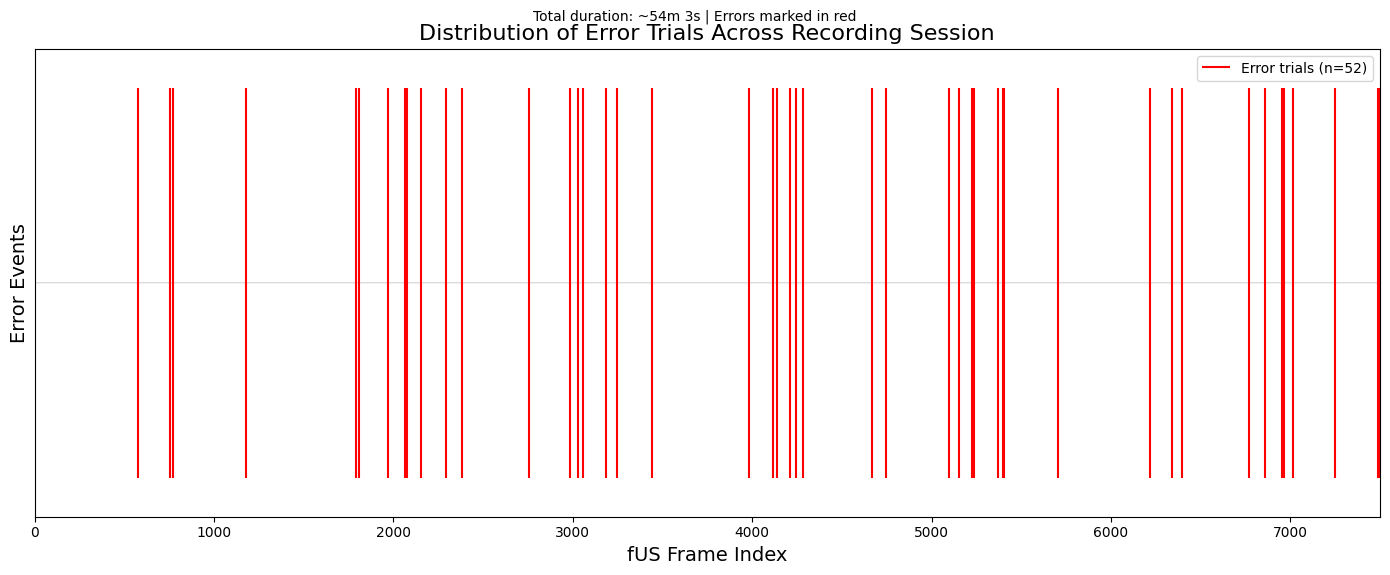


Found 52 error trials.
Error frames: [ 577  756  772 1178 1793 1809 1970 2065 2076 2154 2293 2384 2755 2986
 3031 3058 3184 3246 3442 3981 4116 4139 4208 4246 4283 4669 4743 5095
 5155 5226 5234 5372 5396 5405 5705 6217 6338 6393 6770 6859 6954 6962
 7013 7247 7490 7499 7499 7499 7499 7499 7499 7499]
First error at frame 577 (~487.8s)
Last error at frame 7499 (~3490.2s)


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume these are already defined in your workspace:
# - centers: np.array [n_frames] - timestamps in ms for each fUS frame
# - fus_df: pd.DataFrame - with columns 'saccade_time' (ms), 'outcome' ('success' or 'error')
#   (or use 'cue_time' if you prefer cue onsets instead of saccades)

acquisition = "Se01072020"

centers = np.load(rf"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\behavioral\{acquisition}_centers.npy")

fus_df = pd.read_csv(rf"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\behavioral\{acquisition}_trials.csv")

# Parameters
frame_numbers = np.arange(len(centers))  # X-axis: frame index (0 to n_frames-1)

# Find frame indices closest to error saccade_times
error_df = fus_df[fus_df['outcome'] == 'error']

if not error_df.empty:
    error_saccade_times = error_df['saccade_time'].values  # ms
    # Find the closest frame index for each error saccade
    error_frame_indices = []
    for t in error_saccade_times:
        idx = np.argmin(np.abs(centers - t))
        error_frame_indices.append(idx)
    
    error_frame_indices = np.array(error_frame_indices)
else:
    print("No error trials found in fus_df.")
    error_frame_indices = np.array([])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(frame_numbers, np.zeros_like(frame_numbers), color='lightgray', linewidth=0.8)  # Baseline at y=0

if len(error_frame_indices) > 0:
    plt.vlines(error_frame_indices, ymin=-1, ymax=1, color='red', linewidth=1.5, label=f'Error trials (n={len(error_frame_indices)})')

plt.xlabel('fUS Frame Index', fontsize=14)
plt.ylabel('Error Events', fontsize=14)
plt.title('Distribution of Error Trials Across Recording Session', fontsize=16)
plt.xlim(0, len(centers) - 1)
plt.ylim(-1.2, 1.2)
plt.yticks([])  # Hide y-ticks since it's just event markers
plt.legend(loc='upper right')

# Optional: Add time in minutes/seconds on top axis
total_seconds = (centers[-1] - centers[0]) / 1000
minutes = int(total_seconds // 60)
seconds = int(total_seconds % 60)
plt.suptitle(f'Total duration: ~{minutes}m {seconds}s | Errors marked in red', fontsize=10, y=0.95)

plt.tight_layout()
plt.show()

# Print summary
if len(error_frame_indices) > 0:
    print(f"\nFound {len(error_frame_indices)} error trials.")
    print(f"Error frames: {error_frame_indices}")
    print(f"First error at frame {error_frame_indices[0]} (~{centers[error_frame_indices[0]]/1000:.1f}s)")
    print(f"Last error at frame {error_frame_indices[-1]} (~{centers[error_frame_indices[-1]]/1000:.1f}s)")
else:
    print("No errors to plot.")

C:\Users\leo.sperber\AppData\Local\Temp\ipykernel_4920\1369472757.py:54: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  error_plot_indices = np.where(np.in1d(frame_indices_task, error_frame_indices_task))[0]


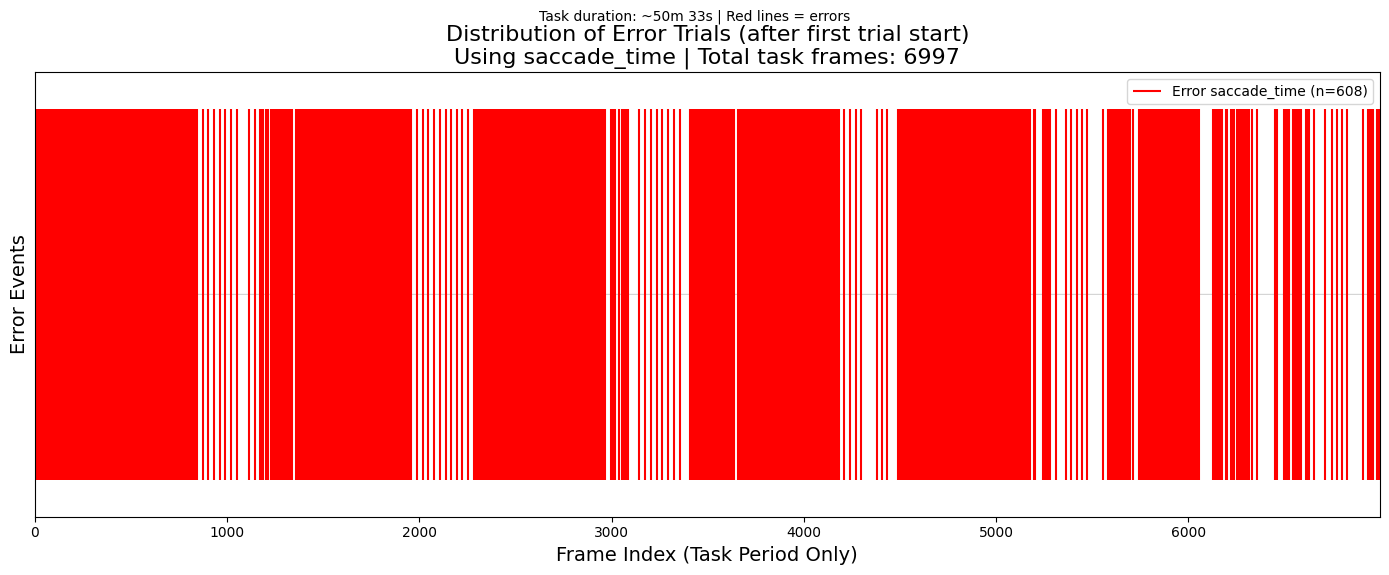


First trial start time: 456494 ms (~456.5s)
Task period frames: 6997 (original frames 503 to 7499)
Errors during task period: 608
First error at task frame 2 (original frame 505)
Last error at task frame 6996 (original frame 7499)


In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume these are already defined:
# - centers: np.array [n_frames] - timestamps in ms
# - fus_df: pd.DataFrame - with 'start_time' (ms) and 'outcome' ('success' or 'error')
# - Optional: 'saccade_time' or 'cue_time' if you want to mark those instead


acquisition = "Se01072020"

centers = np.load(rf"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\behavioral\{acquisition}_centers.npy")

fus_df = pd.read_csv(rf"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\behavioral\{acquisition}_trials.csv")


# Step 1: Find the first trial start time
first_start_time = fus_df['start_time'].min()  # ms

# Step 2: Keep only frames that occur at or after the first trial start
task_mask = centers >= first_start_time
centers_task = centers[task_mask]
frame_indices_task = np.arange(len(centers))[task_mask]  # Original frame numbers for reference

# Step 3: Find error trials and map them to the closest frame AFTER the first trial
error_df = fus_df # [fus_df['outcome'] == 'error']

if not error_df.empty:
    # Use saccade_time if available, otherwise cue_time or start_time
    if 'saccade_time' in error_df.columns:
        error_times = error_df['saccade_time'].values
        event_name = 'saccade_time'
    elif 'cue_time' in error_df.columns:
        error_times = error_df['cue_time'].values
        event_name = 'cue_time'
    else:
        error_times = error_df['start_time'].values
        event_name = 'start_time'
    
    # Find closest frame index in the full centers array, then check if it's in task period
    error_frame_indices_full = []
    for t in error_times:
        idx = np.argmin(np.abs(centers - t))
        error_frame_indices_full.append(idx)
    
    error_frame_indices_full = np.array(error_frame_indices_full)
    
    # Keep only errors that fall within the task period (after first trial)
    valid_error_mask = centers[error_frame_indices_full] >= first_start_time
    error_frame_indices_task = error_frame_indices_full[valid_error_mask]
    
    # Convert to indices within the trimmed task frames (for plotting)
    error_plot_indices = np.where(np.in1d(frame_indices_task, error_frame_indices_task))[0]
else:
    print("No error trials found.")
    error_plot_indices = np.array([])

# Step 4: Plot
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(centers_task)), np.zeros_like(centers_task), color='lightgray', linewidth=0.8)

if len(error_plot_indices) > 0:
    plt.vlines(error_plot_indices, ymin=-1, ymax=1, color='red', linewidth=1.5,
                 label=f'Error {event_name} (n={len(error_plot_indices)})')

plt.xlabel('Frame Index (Task Period Only)', fontsize=14)
plt.ylabel('Error Events', fontsize=14)
plt.title(f'Distribution of Error Trials (after first trial start)\n'
          f'Using {event_name} | Total task frames: {len(centers_task)}', fontsize=16)
plt.xlim(0, len(centers_task) - 1)
plt.ylim(-1.2, 1.2)
plt.yticks([])
plt.legend(loc='upper right')

# Add secondary x-axis with approximate time since task start
task_duration_sec = (centers_task[-1] - centers_task[0]) / 1000
minutes = int(task_duration_sec // 60)
seconds = int(task_duration_sec % 60)
plt.suptitle(f'Task duration: ~{minutes}m {seconds}s | Red lines = errors', fontsize=10, y=0.95)

plt.tight_layout()
plt.show()

# Summary print
print(f"\nFirst trial start time: {first_start_time} ms (~{first_start_time/1000:.1f}s)")
print(f"Task period frames: {len(centers_task)} (original frames {frame_indices_task[0]} to {frame_indices_task[-1]})")
if len(error_plot_indices) > 0:
    print(f"Errors during task period: {len(error_plot_indices)}")
    print(f"First error at task frame {error_plot_indices[0]} (original frame {error_frame_indices_task[0]})")
    print(f"Last error at task frame {error_plot_indices[-1]} (original frame {error_frame_indices_task[-1]})")
else:
    print("No errors occurred after the first trial start.")

C:\Users\leo.sperber\AppData\Local\Temp\ipykernel_4920\2646651366.py:54: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  blink_plot_indices = np.where(np.in1d(frame_indices_task, blink_frame_indices_task))[0]


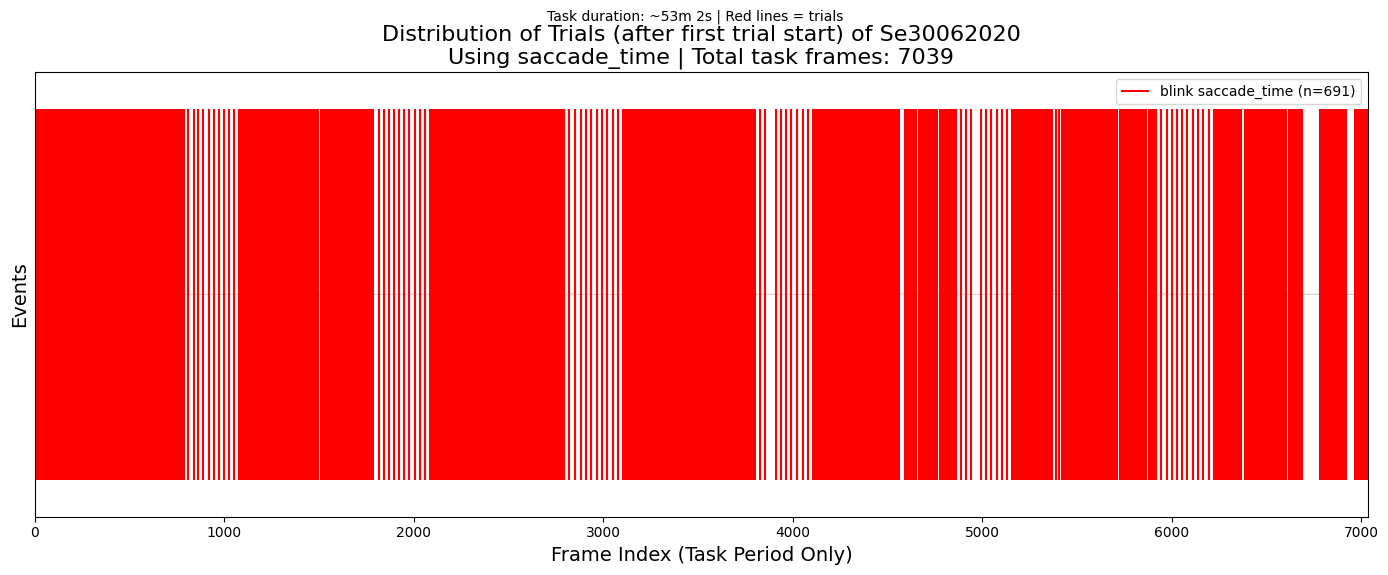


First trial start time: 410569 ms (~410.6s)
Task period frames: 7039 (original frames 461 to 7499)
Trials during task period: 691
First trial at task frame 1 (original frame 462)
Last trial at task frame 7038 (original frame 7499)


In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assume these are already defined:
# - centers: np.array [n_frames] - timestamps in ms
# - fus_df: pd.DataFrame - with 'start_time' (ms) and 'outcome' ('success' or 'error')
# - Optional: 'saccade_time' or 'cue_time' if you want to mark those instead


acquisition = "Se30062020"

centers = np.load(rf"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\behavioral\{acquisition}_centers.npy")

fus_df = pd.read_csv(rf"C:\Users\leo.sperber\FUSclass\modelV1\OOP_secundo\behavioral\{acquisition}_trials.csv")


# Step 1: Find the first trial start time
first_start_time = fus_df['start_time'].min()  # ms

# Step 2: Keep only frames that occur at or after the first trial start
task_mask = centers >= first_start_time
centers_task = centers[task_mask]
frame_indices_task = np.arange(len(centers))[task_mask]  # Original frame numbers for reference

# Step 3: Find error trials and map them to the closest frame AFTER the first trial
blink_df = fus_df#[fus_df['outcome'] == 'blink']

if not blink_df.empty:
    # Use saccade_time if available, otherwise cue_time or start_time
    if 'saccade_time' in blink_df.columns:
        blink_times = blink_df['saccade_time'].values
        event_name = 'saccade_time'
    elif 'cue_time' in blink_df.columns:
        blink_times = blink_df['cue_time'].values
        event_name = 'cue_time'
    else:
        blink_times = blink_df['start_time'].values
        event_name = 'start_time'
    
    # Find closest frame index in the full centers array, then check if it's in task period
    blink_frame_indices_full = []
    for t in blink_times:
        idx = np.argmin(np.abs(centers - t))
        blink_frame_indices_full.append(idx)
    
    blink_frame_indices_full = np.array(blink_frame_indices_full)
    
    # Keep only blink that fall within the task period (after first trial)
    valid_blink_mask = centers[blink_frame_indices_full] >= first_start_time
    blink_frame_indices_task = blink_frame_indices_full[valid_blink_mask]
    
    # Convert to indices within the trimmed task frames (for plotting)
    blink_plot_indices = np.where(np.in1d(frame_indices_task, blink_frame_indices_task))[0]
else:
    print("No blink trials found.")
    blink_plot_indices = np.array([])

# Step 4: Plot
plt.figure(figsize=(14, 6))
plt.plot(np.arange(len(centers_task)), np.zeros_like(centers_task), color='lightgray', linewidth=0.8)

if len(blink_plot_indices) > 0:
    plt.vlines(blink_plot_indices, ymin=-1, ymax=1, color='red', linewidth=1.5,
                 label=f'blink {event_name} (n={len(blink_plot_indices)})')

plt.xlabel('Frame Index (Task Period Only)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title(f'Distribution of Trials (after first trial start) of {acquisition}\n'
          f'Using {event_name} | Total task frames: {len(centers_task)}', fontsize=16)
plt.xlim(0, len(centers_task) - 1)
plt.ylim(-1.2, 1.2)
plt.yticks([])
plt.legend(loc='upper right')

# Add secondary x-axis with approximate time since task start
task_duration_sec = (centers_task[-1] - centers_task[0]) / 1000
minutes = int(task_duration_sec // 60)
seconds = int(task_duration_sec % 60)
plt.suptitle(f'Task duration: ~{minutes}m {seconds}s | Red lines = trials', fontsize=10, y=0.95)

plt.tight_layout()
plt.show()

# Summary print
print(f"\nFirst trial start time: {first_start_time} ms (~{first_start_time/1000:.1f}s)")
print(f"Task period frames: {len(centers_task)} (original frames {frame_indices_task[0]} to {frame_indices_task[-1]})")
if len(blink_plot_indices) > 0:
    print(f"Trials during task period: {len(blink_plot_indices)}")
    print(f"First trial at task frame {blink_plot_indices[0]} (original frame {blink_frame_indices_task[0]})")
    print(f"Last trial at task frame {blink_plot_indices[-1]} (original frame {blink_frame_indices_task[-1]})")
else:
    print("No errors occurred after the first trial start.")

In [99]:
fus_df

,start_time,cue_time,saccade_time,reward_time,trial_type,outcome,X,Y,acquisition,actual_direction,expected_direction
0,456494,457115,457592,457669,anti-left,success,[ -1.90348924 -1.90348924 -1.86785449 ... -1...,[0.44751791 0.44159052 0.44159052 ... 0.737959...,Se01072020,left,left
1,460734,461345,461461,461586,pro-left,success,[ 2.47364514 2.46770601 2.46176689 2.461766...,[ 0.37046184 0.38231662 0.38231662 0.382316...,Se01072020,left,left
2,464763,465493,465789,465930,anti-left,blink,[ -1.29769859 -1.29175947 -1.29769859 ... -1...,[0.34675228 0.3408249 0.34675228 ... 6.404544...,Se01072020,left,left
3,468178,468885,469129,469220,pro-right,success,[-0.48997773 -0.48997773 -0.4840386 ... 11.69...,[0.40009879 0.40602618 0.40009879 ... 0.779451...,Se01072020,right,right
4,472636,473223,473315,473411,pro-left,success,[ -1.86191537 -1.85597624 -1.85597624 -1.85...,[-1.51444801 -1.52630279 -1.53223018 -1.526302...,Se01072020,left,left
...,...,...,...,...,...,...,...,...,...,...,...
638,3639213,3639790,3639914,0,anti-right,error,[-3.60207869 -3.59613957 -3.60207869 ... 0.18...,[0.20449494 0.21634972 0.19856755 ... 2.332427...,Se01072020,left,right
639,3642630,3643286,3643574,3643656,anti-left,blink,[ 0.17520416 0.16332591 0.16332591 ... -1...,[2.35613732 2.3679921 2.3679921 ... 7.797480...,Se01072020,left,left
640,3646016,3646892,3647188,3647273,anti-left,blink,[ -3.22197476 -3.22197476 -3.22197476 ... -1...,[1.71005186 1.71005186 1.70412448 ... 6.700913...,Se01072020,left,left
641,3649380,3649850,3650054,3650147,pro-left,success,[ 0.86414254 0.87008166 0.87602079 0.870081...,[ 1.41960978 1.42553717 1.41368239 1.419609...,Se01072020,left,left
